# Label-Free FDR Control on CIFAR-10-C with Baseline Comparisons

**Publication-ready evaluation with baseline methods**

This notebook evaluates:
- **FDR Control Methods:** BC-Min (BH), FDR2, Benjamini-Hochberg
- **Baseline Methods:** DOC, ATC, AC, COT (from "Leveraging Unlabeled Data to Predict Out-of-Distribution Performance")
- **Analysis:** MANO vs Accuracy, comparative plots

All figures are publication-ready (300 DPI, PDF + PNG)

## 1. Setup and Configuration

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy import stats
from scipy.stats import spearmanr
import os
from bisect import bisect
from collections import defaultdict
from typing import Dict, Tuple, Optional, List

# Print versions
print(f"NumPy version: {np.__version__}")
print(f"PyTorch version: {torch.__version__}")

# Set numpy print options
np.set_printoptions(threshold=np.inf)

# Publication-quality matplotlib settings
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 10,
    'figure.titlesize': 18,
    'font.family': 'serif',
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 10

print(f"Device: {DEVICE}")

# Create output directories
os.makedirs('figures/accuracy', exist_ok=True)
os.makedirs('figures/fdr_curves', exist_ok=True)
os.makedirs('figures/mano', exist_ok=True)
os.makedirs('figures/comparison', exist_ok=True)

print("✓ Setup complete")

NumPy version: 2.0.2
PyTorch version: 2.8.0+cu126
Device: cuda
✓ Setup complete


## 2. Baseline Methods (DOC, ATC, AC, COT)

In [2]:
!pip install POT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.3 MB/s eta 0:00:00a 0:00:01


In [3]:

def negentropy(logits):
    """Compute negentropy (negative entropy)."""
    if isinstance(logits, np.ndarray):
        logits = torch.from_numpy(logits).float()
    probs = torch.softmax(logits, dim=1)
    entropy = -(probs * torch.log(probs + 1e-10)).sum(dim=1)
    max_entropy = np.log(logits.shape[1])
    return max_entropy - entropy


def calibration_temp(logits, labels, num_bins=15):
    """Find optimal temperature for calibration."""
    if isinstance(logits, np.ndarray):
        logits = torch.from_numpy(logits).float()
    if isinstance(labels, np.ndarray):
        labels = torch.from_numpy(labels).long()
    
    temps = torch.linspace(0.1, 5.0, 50)
    best_temp = 1.0
    best_ece = float('inf')
    
    for temp in temps:
        scaled_probs = torch.softmax(logits / temp, dim=1)
        confidences, predictions = scaled_probs.max(dim=1)
        accuracies = (predictions == labels).float()
        
        bin_boundaries = torch.linspace(0, 1, num_bins + 1)
        ece = 0.0
        
        for i in range(num_bins):
            mask = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i + 1])
            if mask.sum() > 0:
                bin_conf = confidences[mask].mean()
                bin_acc = accuracies[mask].mean()
                ece += mask.float().mean() * torch.abs(bin_conf - bin_acc)
        
        if ece < best_ece:
            best_ece = ece
            best_temp = temp.item()
    
    return best_temp


def _to_tensor(x):
    """Convert numpy array or tensor to torch tensor."""
    if isinstance(x, np.ndarray):
        return torch.from_numpy(x).float()
    return x


def predict_ATC_maxconf(source_logits, source_labels, target_logits):
    """Average Threshold Confidence with max confidence."""
    source_logits = _to_tensor(source_logits)
    source_labels = _to_tensor(source_labels).long()
    target_logits = _to_tensor(target_logits)
    
    source_scores = torch.softmax(source_logits, dim=1).amax(1)
    target_scores = torch.softmax(target_logits, dim=1).amax(1)
    sorted_source_scores, _ = torch.sort(source_scores)
    threshold = sorted_source_scores[-(source_logits.argmax(1) == source_labels).sum()]
    estimate = (target_scores > threshold).float().mean().item()
    return estimate


def predict_ATC_negent(source_logits, source_labels, target_logits):
    """Average Threshold Confidence with negentropy."""
    source_logits = _to_tensor(source_logits)
    source_labels = _to_tensor(source_labels).long()
    target_logits = _to_tensor(target_logits)
    
    source_scores = negentropy(source_logits)
    target_scores = negentropy(target_logits)
    sorted_source_scores, _ = torch.sort(source_scores)
    threshold = sorted_source_scores[-(source_logits.argmax(1) == source_labels).sum()]
    estimate = (target_scores > threshold).float().mean().item()
    return estimate


def predict_AC(source_logits, source_labels, target_logits):
    """Average Confidence."""
    target_logits = _to_tensor(target_logits)
    return torch.softmax(target_logits, dim=1).amax(1).mean().item()


def predict_DOC(source_logits, source_labels, target_logits):
    """Difference of Confidences."""
    source_logits = _to_tensor(source_logits)
    source_labels = _to_tensor(source_labels).long()
    target_logits = _to_tensor(target_logits)
    
    avg_source_conf = torch.softmax(source_logits, dim=1).amax(1).mean().item()
    avg_target_conf = torch.softmax(target_logits, dim=1).amax(1).mean().item()
    source_acc = (source_logits.argmax(1) == source_labels).float().mean().item()
    return source_acc + (avg_target_conf - avg_source_conf)


try:
    import ot
    
    def predict_COT(source_logits, source_labels, target_logits):
        """Confidence Optimal Transport."""
        source_logits = _to_tensor(source_logits)
        source_labels = _to_tensor(source_labels).long()
        target_logits = _to_tensor(target_logits)
        
        num_classes = source_logits.shape[1]
        source_label_dist = torch.nn.functional.one_hot(source_labels, num_classes).float().mean(0)
        target_probs = torch.softmax(target_logits, dim=1)
        
        cost_matrix = torch.stack([
            (target_probs - onehot).abs().sum(1)
            for onehot in torch.eye(num_classes, device=target_logits.device)
        ], dim=1) / 2
        
        # IMPORTANT: ot.emd() requires all arrays to be numpy
        uniform_dist = np.ones(len(target_probs)) / len(target_probs)
        source_dist = source_label_dist.cpu().numpy()
        cost_matrix_np = cost_matrix.cpu().numpy()
        
        ot_plan = ot.emd(uniform_dist, source_dist, cost_matrix_np)
        ot_cost = np.sum(ot_plan * cost_matrix_np)
        
        s_conf = torch.softmax(source_logits, dim=1).amax(1).mean().item()
        s_acc = (source_logits.argmax(1) == source_labels).float().mean().item()
        conf_gap = s_conf - s_acc
        err_est = ot_cost + conf_gap
        return 1. - err_est
    
    COT_AVAILABLE = True
    print("✓ COT available")
except ImportError:
    COT_AVAILABLE = False
    print("⚠ COT unavailable (install: pip install POT)")


BASELINE_METHODS = {
    'ATC': predict_ATC_maxconf,
    'ATC-NE': predict_ATC_negent,
    'AC': predict_AC,
    'DOC': predict_DOC,
}

if COT_AVAILABLE:
    BASELINE_METHODS['COT'] = predict_COT

print(f"✓ Baseline methods: {list(BASELINE_METHODS.keys())}")

2026-04-11 07:20:21.708989: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775892022.154337      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775892022.276419      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775892023.240378      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775892023.240419      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775892023.240423      55 computation_placer.cc:177] computation placer alr

✓ COT available
✓ Baseline methods: ['ATC', 'ATC-NE', 'AC', 'DOC', 'COT']


## 3. Model Architecture (WideResNet)

In [4]:
# WideResNet implementation
class WideBasicBlock(nn.Module):
    def __init__(self, in_planes, out_planes, stride, dropout_rate=0.3):
        super(WideBasicBlock, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.conv1 = nn.Conv2d(in_planes, out_planes, kernel_size=3, padding=1, bias=False)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.bn2 = nn.BatchNorm2d(out_planes)
        self.conv2 = nn.Conv2d(out_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != out_planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False),
            )

    def forward(self, x):
        out = self.dropout(self.conv1(F.relu(self.bn1(x))))
        out = self.conv2(F.relu(self.bn2(out)))
        out += self.shortcut(x)
        return out


class WideResNet(nn.Module):
    def __init__(self, depth=28, widen_factor=10, dropout_rate=0.3, num_classes=10):
        super(WideResNet, self).__init__()
        self.in_planes = 16
        assert ((depth - 4) % 6 == 0), 'Wide-resnet depth should be 6n+4'
        n = (depth - 4) // 6
        k = widen_factor
        nStages = [16, 16*k, 32*k, 64*k]
        
        self.conv1 = nn.Conv2d(3, nStages[0], kernel_size=3, stride=1, padding=1, bias=False)
        self.layer1 = self._wide_layer(WideBasicBlock, nStages[1], n, dropout_rate, stride=1)
        self.layer2 = self._wide_layer(WideBasicBlock, nStages[2], n, dropout_rate, stride=2)
        self.layer3 = self._wide_layer(WideBasicBlock, nStages[3], n, dropout_rate, stride=2)
        self.bn1 = nn.BatchNorm2d(nStages[3], momentum=0.9)
        self.linear1 = nn.Linear(nStages[3], nStages[3])
        self.linear2 = nn.Linear(nStages[3], num_classes)
        self.feature_dim = nStages[3]
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def _wide_layer(self, block, planes, num_blocks, dropout_rate, stride):
        strides = [stride] + [1]*(int(num_blocks)-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride, dropout_rate))
            self.in_planes = planes
        return nn.Sequential(*layers)
    
    def get_features(self, x):
        out = self.conv1(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.relu(self.bn1(out))
        out = F.adaptive_avg_pool2d(out, 1)
        out = out.view(out.size(0), -1)
        return out

    def forward(self, x):
        out = self.get_features(x)
        out = self.linear2(F.relu(self.linear1(out)))
        return out


class CIFAR10CDataset(Dataset):
    def __init__(self, data_path, corruption_type, severity, transform=None):
        corruption_file = f"{data_path}/{corruption_type}.npy"
        all_images = np.load(corruption_file)
        labels_file = f"{data_path}/labels.npy"
        all_labels = np.load(labels_file)
        start_idx = (severity - 1) * 10000
        end_idx = severity * 10000
        self.images = all_images[start_idx:end_idx]
        self.labels = all_labels[start_idx:end_idx]
        self.transform = transform
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        else:
            image = torch.from_numpy(image).float() / 255.0
            image = image.permute(2, 0, 1)
        return image, label


class ScoreFeatureDataset(Dataset):
    def __init__(self, cnn_scores, features, target_decoy_scores, labels):
        self.cnn_scores = cnn_scores
        self.target_decoy_scores = target_decoy_scores
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.cnn_scores)

    def __getitem__(self, idx):
        return (self.cnn_scores[idx], self.features[idx], 
                self.target_decoy_scores[idx], self.labels[idx])

print("✓ Model classes defined")

✓ Model classes defined


## 4. Normalizing Flows (SeparateClassFlows)

**TODO:** Add your SeparateClassFlows implementation here

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm


# ─────────────────────────────────────────────────────────────────────────────
# Building blocks
# ─────────────────────────────────────────────────────────────────────────────

class ActNorm(nn.Module):
    """
    Activation normalization — data-driven per-channel scale+bias.
    Initialized from the first batch so the output has mean=0, std=1.
    """
    def __init__(self, dim):
        super().__init__()
        self.dim       = dim
        self.log_scale = nn.Parameter(torch.zeros(dim))
        self.bias      = nn.Parameter(torch.zeros(dim))
        self.initialized = False

    def forward(self, x, reverse=False):
        if not self.initialized:
            with torch.no_grad():
                self.bias.data      = -x.mean(0)
                self.log_scale.data = -x.std(0).clamp(min=1e-6).log()
            self.initialized = True

        if not reverse:
            y       = (x + self.bias) * self.log_scale.exp()
            log_det = self.log_scale.sum().expand(x.size(0))
            return y, log_det
        else:
            x       = x * (-self.log_scale).exp() - self.bias
            log_det = -self.log_scale.sum().expand(x.size(0))
            return x, log_det


class CouplingLayer(nn.Module):
    """
    Affine coupling layer operating on the full score vector (dim=10).
    Conditioned on CNN features.

    Split: x1 = x[:d],  x2 = x[d:]
    Forward:  z2 = x2 * exp(s(x1, feat)) + t(x1, feat)
    Reverse:  x2 = (z2 - t) * exp(-s)
    """
    def __init__(self, dim, feature_dim, hidden_dim=256, mask_type='first_half'):
        super().__init__()
        self.dim       = dim
        self.mask_type = mask_type

        if mask_type == 'first_half':
            self.d_in  = dim // 2          # conditioner input size
            self.d_out = dim - dim // 2    # transformed size
        else:
            self.d_in  = dim - dim // 2
            self.d_out = dim // 2

        net_in = self.d_in + feature_dim

        self.net = nn.Sequential(
            nn.Linear(net_in, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
        )
        self.scale_head     = nn.Sequential(nn.Linear(hidden_dim // 2, self.d_out), nn.Tanh())
        self.translate_head = nn.Linear(hidden_dim // 2, self.d_out)

        # Initialize to identity
        nn.init.zeros_(self.scale_head[0].weight)
        nn.init.zeros_(self.scale_head[0].bias)
        nn.init.zeros_(self.translate_head.weight)
        nn.init.zeros_(self.translate_head.bias)

    def _split(self, x):
        if self.mask_type == 'first_half':
            return x[:, :self.d_in], x[:, self.d_in:]
        else:
            return x[:, self.d_out:], x[:, :self.d_out]

    def _merge(self, x1, x2):
        if self.mask_type == 'first_half':
            return torch.cat([x1, x2], dim=1)
        else:
            return torch.cat([x2, x1], dim=1)

    def forward(self, x, features, reverse=False):
        x1, x2     = self._split(x)
        cond_input = torch.cat([x1, features], dim=1)
        h          = self.net(cond_input)
        s          = self.scale_head(h)
        t          = self.translate_head(h)

        if not reverse:
            z2      = x2 * torch.exp(s) + t
            log_det = s.sum(dim=1)
            return self._merge(x1, z2), log_det
        else:
            x2_rec  = (x2 - t) * torch.exp(-s)
            log_det = -s.sum(dim=1)
            return self._merge(x1, x2_rec), log_det


# ─────────────────────────────────────────────────────────────────────────────
# Main flow: models the full 10-dim score vector shift under distribution shift
# ─────────────────────────────────────────────────────────────────────────────

class ScoreShiftFlow(nn.Module):
    """
    Single normalizing flow that models P(decoy_score_vector | features).

    Goal: learn how the full 10-class score vector looks under the null
    (i.e., when the prediction is wrong / sample is from a different class).

    Architecture:
      - n_flows coupling layers, alternating mask type
      - ActNorm between each pair of layers
      - Feature encoder compresses CNN features before conditioning

    Input  : score_vector ∈ R^10, features ∈ R^feature_dim
    Output : latent z ∈ R^10  (standard normal under null)
    """
    def __init__(self,
                 score_dim   = 10,
                 feature_dim = 640,
                 n_flows     = 12,
                 hidden_dim  = 256,
                 encoder_dim = 128):
        super().__init__()
        self.score_dim   = score_dim
        self.feature_dim = feature_dim
        self.n_flows     = n_flows

        # Feature encoder: compress 640 → encoder_dim
        self.feature_encoder = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Linear(256, encoder_dim),
            nn.LayerNorm(encoder_dim),
            nn.GELU(),
        )

        # Alternating coupling layers + actnorm
        self.layers = nn.ModuleList()
        for i in range(n_flows):
            mask = 'first_half' if i % 2 == 0 else 'second_half'
            self.layers.append(CouplingLayer(score_dim, encoder_dim,
                                             hidden_dim, mask))
            if i < n_flows - 1:
                self.layers.append(ActNorm(score_dim))

        self._log_2pi = np.log(2 * np.pi)

    def encode(self, features):
        """Compress raw CNN features."""
        return self.feature_encoder(features)

    def forward(self, scores, features, reverse=False):
        """
        Forward  : scores → latent z,  returns (z, log_det)
        Reverse  : latent z → scores,  returns (scores, log_det)
        """
        enc = self.encode(features)

        if not reverse:
            x           = scores
            log_det_sum = torch.zeros(x.size(0), device=x.device)

            for layer in self.layers:
                if isinstance(layer, ActNorm):
                    x, ld = layer(x, reverse=False)
                else:
                    x, ld = layer(x, enc, reverse=False)
                log_det_sum = log_det_sum + ld
            return x, log_det_sum

        else:
            z           = scores   # input is latent when reverse=True
            log_det_sum = torch.zeros(z.size(0), device=z.device)

            for layer in reversed(self.layers):
                if isinstance(layer, ActNorm):
                    z, ld = layer(z, reverse=True)
                else:
                    z, ld = layer(z, enc, reverse=True)
                log_det_sum = log_det_sum + ld
            return z, log_det_sum

    def log_prob(self, scores, features):
        """log P(scores | features) under the learned null distribution."""
        z, log_det = self.forward(scores, features, reverse=False)
        log_pz     = -0.5 * (z ** 2 + self.log_2pi_const(z)).sum(dim=1)
        return log_pz + log_det

    def log_2pi_const(self, z):
        return torch.full_like(z, self.score_dim * self._log_2pi / self.score_dim)

    def log_prob(self, scores, features):
        z, log_det = self.forward(scores, features, reverse=False)
        log_pz     = -0.5 * (z ** 2).sum(dim=1) \
                     - 0.5 * self.score_dim * self._log_2pi
        return log_pz + log_det

    def sample(self, features, n_samples=1):
        """Sample decoy score vectors conditioned on features."""
        batch_size = features.size(0)
        z          = torch.randn(batch_size, self.score_dim, device=features.device)
        with torch.no_grad():
            scores, _ = self.forward(z, features, reverse=True)
        return scores   # (batch_size, score_dim)


# ─────────────────────────────────────────────────────────────────────────────
# Wrapper: same API as SeparateClassFlows
# ─────────────────────────────────────────────────────────────────────────────

class ScoreShiftFlowWrapper(nn.Module):
    """
    Drop-in replacement for SeparateClassFlows.

    Key difference: models the FULL score vector shift jointly,
    not each class independently. This captures inter-class correlations
    and better models how the score vector deforms under distribution shift.

    Null construction:
      target_decoy[i] = original score vector with true-class score
                        replaced by a negative-class score.
      The flow learns P(this null vector | features).
      At test time we sample null vectors and compare max(target) vs max(null).
    """
    def __init__(self,
                 num_classes = 10,
                 n_flows     = 12,
                 feature_dim = 640,
                 hidden_dim  = 256,
                 encoder_dim = 128):
        super().__init__()
        self.num_classes = num_classes
        self.flow = ScoreShiftFlow(
            score_dim   = num_classes,
            feature_dim = feature_dim,
            n_flows     = n_flows,
            hidden_dim  = hidden_dim,
            encoder_dim = encoder_dim,
        )

    # ── Training ──────────────────────────────────────────────────────────────

    def train_flow(self,
                   score_dataset,
                   epochs      = 30,
                   lr          = 3e-4,
                   batch_size  = 256,
                   device      = 'cuda',
                   patience    = 5,
                   grad_clip   = 1.0):
        """
        Train the single flow on the full null score vectors.

        Uses:
          - Cosine annealing LR schedule
          - Gradient clipping
          - Early stopping on training loss
        """
        self.flow.to(device)
        self.flow.train()

        loader    = DataLoader(score_dataset, batch_size=batch_size,
                               shuffle=True, num_workers=0, pin_memory=True)
        optimizer = torch.optim.AdamW(self.flow.parameters(), lr=lr,
                                      weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs, eta_min=lr * 0.01)

        best_loss  = float('inf')
        no_improve = 0

        for epoch in range(epochs):
            total_loss = 0.0
            n_batches  = 0

            for cnn_scores, features, target_decoy, labels in loader:
                features     = features.to(device)
                target_decoy = target_decoy.to(device)   # (B, 10) null score vector

                log_prob = self.flow.log_prob(target_decoy, features)
                loss     = -log_prob.mean()

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.flow.parameters(), grad_clip)
                optimizer.step()

                total_loss += loss.item()
                n_batches  += 1

            scheduler.step()
            avg_loss = total_loss / max(n_batches, 1)

            if (epoch + 1) % 5 == 0:
                print(f"  Epoch {epoch+1:3d}/{epochs}  "
                      f"loss={avg_loss:.4f}  "
                      f"lr={scheduler.get_last_lr()[0]:.2e}")

            # Early stopping
            if avg_loss < best_loss - 1e-4:
                best_loss  = avg_loss
                no_improve = 0
                # Save best weights
                best_state = {k: v.clone() for k, v in self.flow.state_dict().items()}
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f"  Early stopping at epoch {epoch+1}")
                    self.flow.load_state_dict(best_state)
                    break

        print(f"  ✓ Training complete. Best loss: {best_loss:.4f}")
        return self

    # ── Inference ─────────────────────────────────────────────────────────────

    def generate_decoys(self, score_dataset, device='cuda', n_samples=1):
        """
        Generate null score vectors for each sample.

        Returns:
          model_scores  : (N, 10)  original CNN logits
          decoy_scores  : (N, 10)  sampled null score vectors
          labels        : (N,)     true labels
        """
        self.flow.to(device)
        self.flow.eval()

        cnn_scores_list  = []
        decoy_scores_list = []
        labels_list      = []

        loader = DataLoader(score_dataset, batch_size=256,
                            shuffle=False, num_workers=0)

        with torch.no_grad():
            for cnn_scores, features, target_decoy, labels in loader:
                features = features.to(device)

                # Sample n_samples null vectors and average for stability
                if n_samples == 1:
                    decoy = self.flow.sample(features)   # (B, 10)
                else:
                    samples = torch.stack(
                        [self.flow.sample(features) for _ in range(n_samples)],
                        dim=0)                            # (n_samples, B, 10)
                    decoy = samples.mean(dim=0)           # (B, 10)

                cnn_scores_list.append(cnn_scores.cpu().numpy())
                decoy_scores_list.append(decoy.cpu().numpy())
                labels_list.append(labels.cpu().numpy())

        return (np.concatenate(cnn_scores_list,   axis=0),
                np.concatenate(decoy_scores_list,  axis=0),
                np.concatenate(labels_list,        axis=0))


# ─────────────────────────────────────────────────────────────────────────────
# Updated dataset creation — null = full score vector with true class replaced
# ─────────────────────────────────────────────────────────────────────────────

def collect_negative_scores(model, train_dataset, num_classes=10, device='cuda'):
    """Collect negative scores for each class (unchanged)."""
    negative_scores_pools = {i: [] for i in range(num_classes)}
    model.eval()
    loader = DataLoader(train_dataset, batch_size=64, shuffle=False)

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Collecting negative scores'):
            images, labels = images.to(device), labels.to(device)
            features = model.get_features(images)
            scores   = model.linear2(F.relu(model.linear1(features)))

            for class_idx in range(num_classes):
                neg_mask = labels != class_idx
                if neg_mask.sum() > 0:
                    negative_scores_pools[class_idx].append(
                        scores[neg_mask, class_idx].cpu())

    for class_idx in range(num_classes):
        if negative_scores_pools[class_idx]:
            negative_scores_pools[class_idx] = \
                torch.cat(negative_scores_pools[class_idx]).numpy()
        else:
            negative_scores_pools[class_idx] = np.array([])

    return negative_scores_pools


def create_score_feature_dataset(dataset, cnn_model, negative_scores_pools,
                                  device='cuda'):
    """
    Create dataset where:
      cnn_scores    = original logit vector  (10,)
      features      = CNN penultimate features (640,)
      target_decoy  = null score vector:
                        same as cnn_scores EXCEPT true-class score
                        is replaced by a random negative score.
                        This teaches the flow what the score vector looks like
                        when the sample does NOT belong to its true class.
      labels        = true class
    """
    cnn_scores_list    = []
    features_list      = []
    target_decoy_list  = []
    labels_list        = []

    cnn_model.eval()
    loader = DataLoader(dataset, batch_size=64, shuffle=False)

    with torch.no_grad():
        for images, labels in tqdm(loader,
                                   desc='Creating score dataset', leave=False):
            images   = images.to(device)
            features = cnn_model.get_features(images)
            scores   = cnn_model.linear2(F.relu(cnn_model.linear1(features)))

            scores_cpu   = scores.cpu()
            features_cpu = features.cpu()

            # Null vector: replace true-class score with negative score
            null_vectors = scores_cpu.clone()
            for i, label in enumerate(labels):
                label_val = label.item()
                neg_pool  = negative_scores_pools[label_val]
                if len(neg_pool) > 0:
                    neg_score = np.random.choice(neg_pool)
                    null_vectors[i, label_val] = torch.tensor(
                        neg_score, dtype=null_vectors.dtype)

            cnn_scores_list.append(scores_cpu)
            features_list.append(features_cpu)
            target_decoy_list.append(null_vectors)
            labels_list.append(labels)

    class ScoreDataset:
        def __init__(self, scores, features, decoys, labels):
            self.cnn_scores          = scores
            self.features            = features
            self.target_decoy_scores = decoys
            self.labels              = labels

        def __len__(self):
            return len(self.cnn_scores)

        def __getitem__(self, idx):
            return (self.cnn_scores[idx], self.features[idx],
                    self.target_decoy_scores[idx], self.labels[idx])

    return ScoreDataset(
        torch.cat(cnn_scores_list),
        torch.cat(features_list),
        torch.cat(target_decoy_list),
        torch.cat(labels_list),
    )


print("✓ ScoreShiftFlow defined — single flow over full score vector")

✓ ScoreShiftFlow defined — single flow over full score vector


## 5. Helper Functions

In [6]:
def collect_negative_scores(model, train_dataset, num_classes=10, device='cuda'):
    """Collect negative scores for decoy generation."""
    negative_scores_pools = {i: [] for i in range(num_classes)}
    
    model.eval()
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
    
    with torch.no_grad():
        for images, labels in tqdm(train_loader, desc='Collecting negative scores'):
            images, labels = images.to(device), labels.to(device)
            features = model.get_features(images)
            scores = model.linear2(F.relu(model.linear1(features)))
            
            for class_idx in range(num_classes):
                neg_mask = labels != class_idx
                if neg_mask.sum() > 0:
                    class_scores = scores[neg_mask, class_idx]
                    negative_scores_pools[class_idx].append(class_scores.cpu())
    
    for class_idx in range(num_classes):
        if negative_scores_pools[class_idx]:
            negative_scores_pools[class_idx] = torch.cat(negative_scores_pools[class_idx]).numpy()
        else:
            negative_scores_pools[class_idx] = np.array([])
    
    return negative_scores_pools



def create_score_feature_dataset(dataset, cnn_model, negative_scores_pools, device='cuda'):
    """Create dataset with scores and features."""
    cnn_scores_list, features_list, target_decoy_list, labels_list = [], [], [], []
    cnn_model.eval()
    
    with torch.no_grad():
        data_loader = DataLoader(dataset, batch_size=64, shuffle=False)
        for images, labels in tqdm(data_loader, desc='Creating score dataset', leave=False):
            images = images.to(device)
            features = cnn_model.get_features(images)
            scores = cnn_model.linear2(F.relu(cnn_model.linear1(features)))
            
            scores_cpu = scores.cpu()
            features_cpu = features.cpu()
            target_decoy_scores = scores_cpu.clone()
            
            for i, label in enumerate(labels):
                label_val = label.item()
                neg_pool = negative_scores_pools[label_val]
                if len(neg_pool) > 0:
                    random_neg_score = np.random.choice(neg_pool)
                    target_decoy_scores[i, label_val] = torch.tensor(random_neg_score, 
                                                                     dtype=target_decoy_scores.dtype)
            
            cnn_scores_list.append(scores_cpu)
            features_list.append(features_cpu)
            target_decoy_list.append(target_decoy_scores)
            labels_list.append(labels)
    
    class ScoreDataset:
        def __init__(self, scores, features, decoys, labels):
            self.cnn_scores = scores
            self.features = features
            self.target_decoy_scores = decoys
            self.labels = labels
        
        def __len__(self):
            return len(self.cnn_scores)
        
        def __getitem__(self, idx):
            return (self.cnn_scores[idx], self.features[idx], 
                    self.target_decoy_scores[idx], self.labels[idx])
    
    return ScoreDataset(torch.cat(cnn_scores_list), torch.cat(features_list),
                       torch.cat(target_decoy_list), torch.cat(labels_list))

## 6. FDR Control Functions

Implementation continues as before...

In [37]:
def empirical_p_values(distribution, query):
    """Calculate empirical p-values from decoy distribution."""
    dist_len = len(distribution)
    p_values = np.zeros(len(query))
    sorted_dist = np.sort(distribution)
    for i, score in enumerate(query):
        p_values[i] = (dist_len - bisect(sorted_dist, score)) / dist_len
    return p_values


def estimate_pi0_storey(p_values, lambda_range=np.arange(0.05, 0.95, 0.05)):
    """Estimate proportion of nulls using Storey's method (LABEL-FREE)."""
    pi0_estimates = [np.mean(p_values > lam) / (1 - lam) for lam in lambda_range]
    return min(1.0, max(0, np.mean(pi0_estimates)))


def benjamini_hochberg(p_values, pi0=1.0):
    """Standard Benjamini-Hochberg procedure with π₀ adjustment."""
    n = len(p_values)
    sorted_idx = np.argsort(p_values)
    sorted_p = p_values[sorted_idx]
    q_values = np.zeros(n)
    
    for i in range(n):
        q = min(1.0, (n * sorted_p[i] * pi0) / (i + 1))
        q_values[i] = q
    
    # Enforce monotonicity
    for i in range(n-2, -1, -1):
        q_values[i] = min(q_values[i], q_values[i+1])
    
    # Map back to original order
    original_q = np.zeros(n)
    original_q[sorted_idx] = q_values
    return original_q


def calculate_fdr2_qvalues(target_scores, decoy_scores):
    """Calculate FDR2 q-values using TDC (LABEL-FREE)."""
    n = len(target_scores)
    combined_scores = np.maximum(target_scores, decoy_scores)
    is_target_win = (target_scores > decoy_scores).astype(int)
    
    sort_idx = np.argsort(combined_scores)[::-1]
    sorted_wins = is_target_win[sort_idx]
    
    fdr2_values = np.zeros(n)
    n_decoy_wins = 0
    
    for i in range(n):
        if sorted_wins[i] == 0:
            n_decoy_wins += 1
        fdr2_values[i] = (2 * n_decoy_wins) / (i + 1) if (i + 1) > 0 else 0
    
    # Enforce monotonicity
    q_fdr2 = np.minimum.accumulate(fdr2_values[::-1])[::-1]
    
    # Map back to original order
    final_q_fdr2 = np.zeros(n)
    for i in range(n):
        final_q_fdr2[sort_idx[i]] = q_fdr2[i]
    
    return final_q_fdr2


def calculate_mixmax_qvalues(model_scores, decoy_scores):
    """
    Mix-Max FDR control from Keich et al. with pi0=0.
    
    With pi0=0, FDP_MM(s_th) simplifies to:
    
    FDP_MM(s_th) = 
        SUM_{Zj > s_th} [ P(f(t) <= Zj) / P(g(t) <= Zj) ]_[0,1]
        ─────────────────────────────────────────────────────────
                        1{ f(t) >= s_th }
    
    Where:
        f(t)  = target score per sample (model score for predicted class)
        Zj    = decoy scores (null distribution)
        g(t)  = mix_max_score = max(f(t), Z) per sample
        s_th  = threshold swept from high to low
    
    P(f(t) <= z)  estimated empirically over all samples
    P(g(t) <= z)  estimated empirically over all samples
    """
    n = len(model_scores)
    pi0 = 0.0

    # ── Scores ────────────────────────────────────────────────────────────
    pred_classes  = model_scores.argmax(axis=1)           # (n,)
    target_scores = model_scores[np.arange(n), pred_classes]  # f(t), shape (n,)
    null_scores   = decoy_scores[np.arange(n), pred_classes]  # Zj,   shape (n,)

    mix_max_scores = np.maximum(target_scores, null_scores)    # g(t), shape (n,)

    print(f"  target_scores : [{target_scores.min():.3f}, {target_scores.max():.3f}]"
          f" mean={target_scores.mean():.3f}")
    print(f"  null_scores   : [{null_scores.min():.3f}, {null_scores.max():.3f}]"
          f" mean={null_scores.mean():.3f}")
    print(f"  mix_max_scores: [{mix_max_scores.min():.3f}, {mix_max_scores.max():.3f}]"
          f" mean={mix_max_scores.mean():.3f}")
    print(f"  target wins   : {(target_scores > null_scores).mean():.3f}")

    # ── Unique null values and their counts ───────────────────────────────
    # We need: for each unique Zj value, 
    #   how many targets f(t) <= Zj  → P_F(Zj)
    #   how many mix_max g(t) <= Zj  → P_G(Zj)
    unique_z, counts_z = np.unique(null_scores, return_counts=True)
    n_unique_z = len(unique_z)
    n_obs      = len(null_scores)

    sorted_targets  = np.sort(target_scores)    # for searchsorted
    sorted_mixmax   = np.sort(mix_max_scores)   # for searchsorted

    # Empirical CDFs at each unique Zj
    # P(f(t) <= z)
    counts_f_leq_z = np.searchsorted(sorted_targets, unique_z, side='right')
    P_F_leq_z      = counts_f_leq_z / n

    # P(g(t) <= z)  where g(t) = mix_max
    counts_g_leq_z = np.searchsorted(sorted_mixmax, unique_z, side='right')
    P_G_leq_z      = counts_g_leq_z / n

    # R_j = [ P(f(t) <= Zj) / P(g(t) <= Zj) ]_[0,1]
    # This is the per-Zj contribution to FDP numerator
    R_j = np.divide(
        P_F_leq_z, P_G_leq_z,
        out=np.zeros_like(P_F_leq_z),
        where=P_G_leq_z > 0
    )
    R_j = np.clip(R_j, 0, 1)

    print(f"  R_j: min={R_j.min():.4f}, max={R_j.max():.4f}, mean={R_j.mean():.4f}")

    # ── Sweep thresholds from high to low ─────────────────────────────────
    # Thresholds = sorted target scores descending
    # At each threshold s_th:
    #   denominator = number of target scores >= s_th = i+1 (discoveries)
    #   numerator   = SUM_{Zj > s_th} R_j[j]
    
    all_thresholds = np.sort(target_scores)[::-1]   # sweep target scores
    fdr_values     = np.zeros(n)

    for i, s_th in enumerate(all_thresholds):
        D = i + 1   # number of discoveries (f(t) >= s_th)

        # Sum over Zj > s_th of R_j
        # unique_z is sorted → find first index where unique_z > s_th
        idx_start = np.searchsorted(unique_z, s_th, side='right')

        if idx_start >= n_unique_z:
            numerator = 0.0
        else:
            # Weight each R_j by how many null scores equal that unique_z value
            numerator = np.sum(R_j[idx_start:] * counts_z[idx_start:])

        fdr_values[i] = numerator / D if D > 0 else 0.0

    print(f"  fdr_values: min={fdr_values.min():.4f}, max={fdr_values.max():.4f}")
    print(f"  fdr_values first 5: {fdr_values[:5]}")

    # ── Monotone q-values ─────────────────────────────────────────────────
    q_values = np.minimum.accumulate(fdr_values[::-1])[::-1]

    print(f"  q_values: min={q_values.min():.4f}, max={q_values.max():.4f}")
    print(f"  unique q_values: {len(np.unique(q_values))}")

    # ── Map back to original order ────────────────────────────────────────
    sorted_idx = np.argsort(target_scores)[::-1]
    final_q    = np.zeros(n)
    final_q[sorted_idx] = q_values

    return final_q


def control_fdr_mixmax(model_scores, target_labels, decoy_scores):
    """Mix-Max FDR control. pi0=0 (no truly null samples)."""
    n_samples = len(model_scores)

    df = pd.DataFrame({
        'original_index'  : np.arange(n_samples),
        'label'           : target_labels,
        'max_model_score' : model_scores.max(axis=1),
        'max_decoy_score' : decoy_scores.max(axis=1),
        'predicted_class' : model_scores.argmax(axis=1),
        'pred_class_score': model_scores[np.arange(n_samples),
                                         model_scores.argmax(axis=1)],
    })

    # Mix-Max q-values
    q_mixmax = calculate_mixmax_qvalues(model_scores, decoy_scores)
    df['q_values_mixmax'] = q_mixmax

    # Ground Truth (oracle, uses labels)
    df_gt = df.sort_values('pred_class_score', ascending=False).reset_index(drop=True)
    num_incorrect = 0
    fdr_gt = []
    for idx, row in df_gt.iterrows():
        if row['predicted_class'] != row['label']:
            num_incorrect += 1
        fdr_gt.append(num_incorrect / (idx + 1))
    q_gt = np.array(fdr_gt)
    for i in range(len(q_gt) - 2, -1, -1):
        q_gt[i] = min(q_gt[i], q_gt[i + 1])
    df_gt['q_values_ground_truth'] = q_gt
    gt_map = dict(zip(df_gt['original_index'], df_gt['q_values_ground_truth']))
    df['q_values_ground_truth'] = df['original_index'].map(gt_map)

    return df


print("✓ Mix-Max (correct formula) loaded")

✓ Mix-Max (correct formula) loaded


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# Accuracy-estimation helpers
# ─────────────────────────────────────────────────────────────────────────────

def estimate_pi0_storey_from_df(df, q_value_column):
    """Estimate π₀ from DataFrame (LABEL-FREE)."""
    if 'p_values' in df.columns:
        p_values = df['p_values'].dropna().values
        if len(p_values) > 0:
            lambda_range = np.arange(0.05, 0.95, 0.05)
            pi0_estimates = [np.mean(p_values > lam) / (1 - lam) for lam in lambda_range]
            return min(1.0, max(0, np.mean(pi0_estimates)))
    
    if 'pi0_storey' in df.columns:
        pi0 = df['pi0_storey'].iloc[0]
        if not np.isnan(pi0):
            return pi0
    
    # Mix-Max: pi0 = 0 by design
    if q_value_column == 'q_values_mixmax':
        return 0.0

    # Fallback: empirical estimate
    score_column = 'max_model_score' if 'max_model_score' in df.columns else 'model_score'
    if score_column not in df.columns:
        return 0.5
    
    df_sorted = df.sort_values(by=score_column, ascending=False).reset_index(drop=True)
    top_k = max(100, int(0.2 * len(df_sorted)))
    top_samples = df_sorted.head(top_k)
    is_correct = (top_samples['predicted_class'] == top_samples['label']).astype(int)
    return np.clip(1 - is_correct.mean(), 0.01, 0.99)


def compute_ground_truth_curve(df):
    """Compute Ground Truth curve (uses labels — oracle)."""
    score_column = 'max_model_score' if 'max_model_score' in df.columns else 'model_score'
    if score_column not in df.columns:
        return pd.DataFrame({'q_value': [0.05], 'accuracy': [0.5]})
    
    df_gt = df.sort_values(by=score_column, ascending=False).reset_index(drop=True)
    
    if 'q_values_ground_truth' in df_gt.columns:
        df_gt = df_gt[~df_gt['q_values_ground_truth'].isna()].copy()
        q_col = 'q_values_ground_truth'
    else:
        df_gt['is_correct'] = (df_gt['predicted_class'] == df_gt['label']).astype(int)
        num_incorrect = 0
        q_values_gt = []
        for idx in range(len(df_gt)):
            if df_gt.loc[idx, 'is_correct'] == 0:
                num_incorrect += 1
            q_values_gt.append(num_incorrect / (idx + 1))
        df_gt['q_values_ground_truth'] = q_values_gt
        q_col = 'q_values_ground_truth'
    
    df_gt['is_correct'] = (df_gt['predicted_class'] == df_gt['label']).astype(int)
    df_gt['n_discoveries'] = np.arange(1, len(df_gt) + 1)
    df_gt['TP_true'] = df_gt['is_correct'].cumsum()
    df_gt['FP_true'] = df_gt['n_discoveries'] - df_gt['TP_true']
    
    total_correct   = df_gt['is_correct'].sum()
    total_incorrect = len(df_gt) - total_correct
    total_samples   = len(df)
    
    df_gt['TN_true']       = total_incorrect - df_gt['FP_true']
    df_gt['FN_true']       = total_correct   - df_gt['TP_true']
    df_gt['Accuracy_true'] = (df_gt['TP_true'] + df_gt['TN_true']) / total_samples
    
    return df_gt[[q_col, 'Accuracy_true']].rename(
        columns={q_col: 'q_value_gt', 'Accuracy_true': 'accuracy_gt'})


def compute_method_estimation_curve(df, q_value_column, pi0):
    """Compute LABEL-FREE estimation curve with correct threshold-matched true accuracy."""
    total_samples = len(df)
    df_method = df[~df[q_value_column].isna()].copy()
    
    if len(df_method) == 0:
        return pd.DataFrame()
    
    # Sort by q-value ascending (best discoveries first)
    df_method = df_method.sort_values(by=q_value_column, ascending=True).reset_index(drop=True)
    df_method['n_discoveries'] = np.arange(1, len(df_method) + 1)
    
    # ── Label-free estimation (pi0=0 for Mix-Max) ─────────────────────────
    df_method['FP_est'] = df_method['n_discoveries'] * df_method[q_value_column]
    df_method['TP_est'] = df_method['n_discoveries'] - df_method['FP_est']
    df_method['TN_est'] = total_samples * pi0 - df_method['FP_est']
    df_method['FN_est'] = total_samples * (1 - pi0) - df_method['TP_est']
    
    df_method['FP_est'] = np.maximum(0, df_method['FP_est'])
    df_method['TP_est'] = np.maximum(0, df_method['TP_est'])
    df_method['TN_est'] = np.maximum(0, df_method['TN_est'])
    df_method['FN_est'] = np.maximum(0, df_method['FN_est'])
    
    df_method['Accuracy_est'] = (df_method['TP_est'] + df_method['TN_est']) / total_samples

    # ── True accuracy AT SAME threshold (uses labels) ─────────────────────
    # For each row i: true accuracy among the top i discoveries
    df_method['is_correct'] = (
        df_method['predicted_class'] == df_method['label']
    ).astype(int)
    
    cum_correct = df_method['is_correct'].cumsum()
    
    # True acc at threshold = correct among accepted / total samples
    # (same denominator as estimated acc)
    df_method['Accuracy_true_at_threshold'] = cum_correct / total_samples

    # Also compute standard cumulative accuracy among accepted only
    df_method['Accuracy_true_among_accepted'] = (
        cum_correct / df_method['n_discoveries']
    )

    # ── Error at each threshold ───────────────────────────────────────────
    df_method['error_at_threshold'] = np.abs(
        df_method['Accuracy_est'] - df_method['Accuracy_true_at_threshold']
    )

    return df_method[[
        q_value_column,
        'n_discoveries',
        'Accuracy_est',
        'Accuracy_true_at_threshold',
        'Accuracy_true_among_accepted',
        'error_at_threshold',
        'FP_est', 'TP_est', 'FN_est', 'TN_est',
        'is_correct',
    ]].rename(columns={q_value_column: 'q_value_method'})

In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# Plotting
# ─────────────────────────────────────────────────────────────────────────────

def plot_accuracy_estimation(df, q_value_column, method_name, corruption_name, save_dir):
    """Plot accuracy estimation curve with threshold-matched true accuracy."""
    os.makedirs(save_dir, exist_ok=True)
    
    pi0       = estimate_pi0_storey_from_df(df, q_value_column)
    df_gt     = compute_ground_truth_curve(df)
    df_method = compute_method_estimation_curve(df, q_value_column, pi0)
    
    if len(df_method) == 0:
        print(f"  No valid data for {corruption_name}")
        return None, pi0
    
    # ── Find best threshold ───────────────────────────────────────────────
    best_idx      = df_method['Accuracy_est'].idxmax()
    best_q        = df_method.loc[best_idx, 'q_value_method']
    best_acc_est  = df_method.loc[best_idx, 'Accuracy_est']
    best_acc_true = df_method.loc[best_idx, 'Accuracy_true_at_threshold']
    best_error    = df_method.loc[best_idx, 'error_at_threshold']
    best_n        = df_method.loc[best_idx, 'n_discoveries']

    # ── Plot ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    
    ax.plot(df_method['q_value_method'], df_method['Accuracy_est'],
            color='#E53935', linewidth=2.5,
            label=f'{method_name} (est)', alpha=0.9)
    
    ax.plot(df_method['q_value_method'], df_method['Accuracy_true_at_threshold'],
            color='#1976D2', linewidth=2.5, linestyle='-.',
            label='True acc @ threshold', alpha=0.9)
    
    ax.plot(df_gt['q_value_gt'], df_gt['accuracy_gt'],
            color='black', linewidth=2.5, linestyle='--',
            label='Ground Truth', alpha=0.7)
    
    # Mark best threshold
    ax.axvline(best_q, color='#E53935', linestyle=':', alpha=0.6, linewidth=1.5)
    ax.scatter([best_q], [best_acc_est],  color='#E53935', s=80, zorder=5)
    ax.scatter([best_q], [best_acc_true], color='#1976D2', s=80, zorder=5)
    
    # FDR reference lines
    for fdr in [0.05, 0.10, 0.20]:
        ax.axvline(fdr, color='gray', linestyle=':', alpha=0.3, linewidth=1)
        ax.text(fdr, 0.02, f'{fdr:.2f}', rotation=0,
                va='bottom', ha='center', fontsize=9, alpha=0.6)
    
    ax.set_xlabel('Q-value (FDR threshold)', fontweight='bold')
    ax.set_ylabel('Accuracy', fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, min(0.5, df_method['q_value_method'].max() + 0.02))
    ax.legend(loc='lower left', frameon=True, framealpha=0.9, fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    corruption_title = corruption_name.replace('_', ' ').title()
    ax.set_title(f'{corruption_title}', fontweight='bold')
    
    filename = f'{save_dir}/accuracy_{corruption_name}'
    plt.savefig(filename + '.png', dpi=300, bbox_inches='tight')
    plt.savefig(filename + '.pdf', bbox_inches='tight')
    plt.close()
    
    print(f"  ✓ {corruption_name}: "
          f"π₀={pi0:.3f}  "
          f"best_q={best_q:.3f}  "
          f"n_accepted={best_n}/{len(df)}  "
          f"est_acc={best_acc_est:.3f}  "
          f"true_acc={best_acc_true:.3f}  "
          f"error={best_error:.3f}")
    
    return df_method, pi0


print("✓ Updated estimation functions loaded")


def plot_fdr_curve(df, corruption_name, save_dir):
    """Plot FDR control curve with Mix-Max (publication quality, 6×4 inches)."""
    os.makedirs(save_dir, exist_ok=True)
    
    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    
    methods = [
        ('q_values_ground_truth', 'Ground Truth',    '#2E7D32', '--', 2.5),
        ('q_values_fdr2',         'FDR2 (TDC)',       '#F57C00', '-',  2.0),
        ('q_values_bh',           'Benjamini-Hochberg','#7B1FA2', '-',  2.0),
        ('q_values_mixmax',       'Mix-Max',           '#E53935', '-',  2.5),
    ]
    
    for col_name, label, color, linestyle, linewidth in methods:
        if col_name not in df.columns:
            continue
        df_plot = df[~df[col_name].isna()].copy()
        if len(df_plot) == 0:
            continue
        df_sorted    = df_plot.sort_values(col_name).reset_index(drop=True)
        q_vals       = df_sorted[col_name].values
        n_discoveries = np.arange(1, len(df_sorted) + 1)
        ax.plot(q_vals, n_discoveries, label=label, linewidth=linewidth,
                color=color, linestyle=linestyle, alpha=0.8)
    
    for fdr in [0.01, 0.05, 0.1]:
        ax.axvline(fdr, color='gray', linestyle=':', alpha=0.4, linewidth=1)
        ax.text(fdr, ax.get_ylim()[1] * 0.95, f'{fdr:.2f}',
                rotation=90, va='top', ha='right', fontsize=9, alpha=0.7)
    
    ax.set_xlabel('Q-value (FDR)', fontweight='bold')
    ax.set_ylabel('Number of Discoveries', fontweight='bold')
    ax.set_xlim(0, 0.2)
    ax.legend(fontsize=9, framealpha=0.9, loc='lower right')
    ax.grid(alpha=0.3, linestyle='--')
    
    corruption_title = corruption_name.replace('_', ' ').title()
    ax.set_title(f'{corruption_title}', fontweight='bold')
    
    filename = f'{save_dir}/fdr_{corruption_name}'
    plt.savefig(filename + '.png', dpi=300, bbox_inches='tight')
    plt.savefig(filename + '.pdf', bbox_inches='tight')
    plt.close()
    print(f"  ✓ {corruption_name}")


def plot_method_comparison(results_df, corruption_name, save_dir='figures/comparison'):
    """Compare all methods for a single corruption (publication quality, 6×4 inches)."""
    os.makedirs(save_dir, exist_ok=True)
    
    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    
    df_corr  = results_df[results_df['corruption'] == corruption_name]
    true_acc = df_corr['true_accuracy'].iloc[0]
    df_sorted = df_corr.sort_values('estimated_accuracy', ascending=False)
    
    methods   = df_sorted['method'].values
    estimates = df_sorted['estimated_accuracy'].values
    errors    = np.abs(estimates - true_acc)
    
    colors = []
    for method in methods:
        if 'Mix-Max' in method:
            colors.append('#E53935')   # Red  – Mix-Max
        elif method in ['FDR2', 'B-H']:
            colors.append('#7B1FA2')   # Purple – other FDR
        else:
            colors.append('#1976D2')   # Blue   – baselines
    
    x_pos = np.arange(len(methods))
    bars  = ax.bar(x_pos, estimates, color=colors, alpha=0.7,
                   edgecolor='black', linewidth=1)
    ax.axhline(true_acc, color='red', linestyle='--', linewidth=2.5,
               label=f'True Accuracy ({true_acc:.3f})', alpha=0.8)
    
    for bar, err in zip(bars, errors):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height + 0.01,
                f'{err:.3f}', ha='center', va='bottom', fontsize=8)
    
    ax.set_xlabel('Method', fontweight='bold')
    ax.set_ylabel('Estimated Accuracy', fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(methods, rotation=45, ha='right', fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.legend(loc='lower right', framealpha=0.9)
    ax.grid(axis='y', alpha=0.3)
    
    corruption_title = corruption_name.replace('_', ' ').title()
    ax.set_title(f'Method Comparison: {corruption_title}', fontweight='bold')
    
    filename = f'{save_dir}/comparison_{corruption_name}'
    plt.savefig(filename + '.png', dpi=300, bbox_inches='tight')
    plt.savefig(filename + '.pdf', bbox_inches='tight')
    plt.close()
    print(f"  ✓ {corruption_name}")


def plot_overall_comparison(results_df, save_dir='figures/comparison'):
    """Overall MAE comparison across all corruptions."""
    os.makedirs(save_dir, exist_ok=True)
    
    mae_data = []
    for method in results_df['method'].unique():
        df_m = results_df[results_df['method'] == method]
        mae  = np.abs(df_m['estimated_accuracy'] - df_m['true_accuracy']).mean()
        mae_data.append({'Method': method, 'MAE': mae})
    mae_df = pd.DataFrame(mae_data).sort_values('MAE')
    
    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
    
    colors = []
    for method in mae_df['Method']:
        if 'Mix-Max' in method:
            colors.append('#E53935')
        elif method in ['FDR2', 'B-H']:
            colors.append('#7B1FA2')
        else:
            colors.append('#1976D2')
    
    x_pos = np.arange(len(mae_df))
    ax.bar(x_pos, mae_df['MAE'], color=colors, alpha=0.7,
           edgecolor='black', linewidth=1)
    
    ax.set_xlabel('Method', fontweight='bold')
    ax.set_ylabel('Mean Absolute Error', fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(mae_df['Method'], rotation=45, ha='right')
    ax.set_title('Overall Performance Across All Corruptions', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    for i, (_, row) in enumerate(mae_df.iterrows()):
        ax.text(i, row['MAE'] + 0.005, f"{row['MAE']:.4f}",
                ha='center', va='bottom', fontsize=9)
    
    filename = f'{save_dir}/overall_comparison'
    plt.savefig(filename + '.png', dpi=300, bbox_inches='tight')
    plt.savefig(filename + '.pdf', bbox_inches='tight')
    plt.close()
    
    print("\n✓ Overall comparison plot saved")
    print("\nMean Absolute Error (MAE) by Method:")
    print(mae_df.to_string(index=False))
    return mae_df


def plot_scatter_estimated_vs_true(results_df, save_dir='figures/comparison'):
    """
    Scatter plot: estimated accuracy vs true accuracy.
    One point per corruption per method.
    Perfect estimation = diagonal line.
    """
    os.makedirs(save_dir, exist_ok=True)

    methods = results_df['method'].unique()

    # ── 1. One plot per method ────────────────────────────────────────────────
    for method in methods:
        df_m = results_df[results_df['method'] == method].copy()

        fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)

        color = '#E53935' if 'Mix-Max' in method else \
                '#7B1FA2' if method in ['FDR2', 'B-H'] else '#1976D2'

        ax.scatter(df_m['true_accuracy'], df_m['estimated_accuracy'],
                   color=color, s=60, alpha=0.8, edgecolors='black', linewidths=0.5,
                   label=method)

        # Annotate each point with corruption name
        for _, row in df_m.iterrows():
            ax.annotate(row['corruption'].replace('_', ' '),
                        (row['true_accuracy'], row['estimated_accuracy']),
                        fontsize=6, alpha=0.7,
                        xytext=(4, 4), textcoords='offset points')

        # Perfect diagonal
        lo = min(df_m['true_accuracy'].min(), df_m['estimated_accuracy'].min()) - 0.02
        hi = max(df_m['true_accuracy'].max(), df_m['estimated_accuracy'].max()) + 0.02
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.5, alpha=0.6, label='Perfect')

        mae = np.abs(df_m['estimated_accuracy'] - df_m['true_accuracy']).mean()
        ax.set_xlabel('True Accuracy', fontweight='bold')
        ax.set_ylabel('Estimated Accuracy', fontweight='bold')
        ax.set_title(f'{method}\nMAE = {mae:.4f}', fontweight='bold')
        ax.legend(fontsize=9, framealpha=0.9)
        ax.grid(True, alpha=0.3, linestyle='--')

        safe_name = method.replace(' ', '_').replace('(', '').replace(')', '').replace('-', '_')
        filename  = f'{save_dir}/scatter_{safe_name}'
        plt.savefig(filename + '.png', dpi=300, bbox_inches='tight')
        plt.savefig(filename + '.pdf', bbox_inches='tight')
        plt.close()

    # ── 2. All methods on one axes ────────────────────────────────────────────
    method_colors = {}
    for method in methods:
        method_colors[method] = (
            '#E53935' if 'Mix-Max' in method else
            '#7B1FA2' if method in ['FDR2', 'B-H'] else
            '#1976D2'
        )

    fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

    for method in methods:
        df_m  = results_df[results_df['method'] == method]
        color = method_colors[method]
        ax.scatter(df_m['true_accuracy'], df_m['estimated_accuracy'],
                   color=color, s=50, alpha=0.75,
                   edgecolors='black', linewidths=0.4,
                   label=method)

    # Perfect diagonal
    all_vals = pd.concat([results_df['true_accuracy'], results_df['estimated_accuracy']])
    lo, hi   = all_vals.min() - 0.02, all_vals.max() + 0.02
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=2, alpha=0.7, label='Perfect estimation')

    ax.set_xlabel('True Accuracy', fontweight='bold')
    ax.set_ylabel('Estimated Accuracy', fontweight='bold')
    ax.set_title('Estimated vs True Accuracy (All Methods)', fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.9, loc='upper left')
    ax.grid(True, alpha=0.3, linestyle='--')

    filename = f'{save_dir}/scatter_all_methods'
    plt.savefig(filename + '.png', dpi=300, bbox_inches='tight')
    plt.savefig(filename + '.pdf', bbox_inches='tight')
    plt.close()

    print("✓ Scatter plots saved")


print("✓ Plotting functions loaded (including Mix-Max + scatter)")

✓ Updated estimation functions loaded
✓ Plotting functions loaded (including Mix-Max + scatter)


## 7. Comparison Plotting Functions

In [11]:
def plot_method_comparison(results_df, corruption_name, save_dir='figures/comparison'):
    """
    Compare all methods (FDR + Baselines) for a single corruption.
    Publication quality 6x4 inches.
    """
    os.makedirs(save_dir, exist_ok=True)
    
    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    
    # Filter for this corruption
    df_corr = results_df[results_df['corruption'] == corruption_name]
    
    # Get ground truth
    true_acc = df_corr['true_accuracy'].iloc[0]
    
    # Sort methods by estimate
    df_sorted = df_corr.sort_values('estimated_accuracy', ascending=False)
    
    methods = df_sorted['method'].values
    estimates = df_sorted['estimated_accuracy'].values
    errors = np.abs(estimates - true_acc)
    
    # Color mapping
    colors = []
    for method in methods:
        if 'BC-Min' in method:
            colors.append('#FF9800')  # Orange - our method
        elif method in ['FDR2', 'B-H']:
            colors.append('#7B1FA2')  # Purple - other FDR
        else:
            colors.append('#1976D2')  # Blue - baselines
    
    # Bar plot
    x_pos = np.arange(len(methods))
    bars = ax.bar(x_pos, estimates, color=colors, alpha=0.7, edgecolor='black', linewidth=1)
    
    # Ground truth line
    ax.axhline(true_acc, color='red', linestyle='--', linewidth=2.5, 
               label=f'True Accuracy ({true_acc:.3f})', alpha=0.8)
    
    # Add error annotations on bars
    for i, (bar, err) in enumerate(zip(bars, errors)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{err:.3f}',
                ha='center', va='bottom', fontsize=8, rotation=0)
    
    ax.set_xlabel('Method', fontweight='bold')
    ax.set_ylabel('Estimated Accuracy', fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(methods, rotation=45, ha='right', fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.legend(loc='lower right', framealpha=0.9)
    ax.grid(axis='y', alpha=0.3)
    
    corruption_title = corruption_name.replace('_', ' ').title()
    ax.set_title(f'Method Comparison: {corruption_title}', fontweight='bold')
    
    filename = f'{save_dir}/comparison_{corruption_name}'
    plt.savefig(filename + '.png', dpi=300, bbox_inches='tight')
    plt.savefig(filename + '.pdf', bbox_inches='tight')
    plt.close()
    
    print(f"  ✓ {corruption_name}")


def plot_overall_comparison(results_df, save_dir='figures/comparison'):
    """
    Overall comparison across all corruptions.
    Shows mean absolute error for each method.
    """
    os.makedirs(save_dir, exist_ok=True)
    
    # Compute MAE for each method
    mae_data = []
    for method in results_df['method'].unique():
        df_method = results_df[results_df['method'] == method]
        mae = np.abs(df_method['estimated_accuracy'] - df_method['true_accuracy']).mean()
        mae_data.append({'Method': method, 'MAE': mae})
    
    mae_df = pd.DataFrame(mae_data).sort_values('MAE')
    
    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
    
    # Color by method type
    colors = []
    for method in mae_df['Method']:
        if 'BC-Min' in method:
            colors.append('#FF9800')
        elif method in ['FDR2', 'B-H']:
            colors.append('#7B1FA2')
        else:
            colors.append('#1976D2')
    
    x_pos = np.arange(len(mae_df))
    ax.bar(x_pos, mae_df['MAE'], color=colors, alpha=0.7, edgecolor='black', linewidth=1)
    
    ax.set_xlabel('Method', fontweight='bold')
    ax.set_ylabel('Mean Absolute Error', fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(mae_df['Method'], rotation=45, ha='right')
    ax.set_title('Overall Performance Across All Corruptions', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, (idx, row) in enumerate(mae_df.iterrows()):
        ax.text(i, row['MAE'] + 0.005, f"{row['MAE']:.4f}",
                ha='center', va='bottom', fontsize=9)
    
    filename = f'{save_dir}/overall_comparison'
    plt.savefig(filename + '.png', dpi=300, bbox_inches='tight')
    plt.savefig(filename + '.pdf', bbox_inches='tight')
    plt.close()
    
    print("\n✓ Overall comparison plot saved")
    print("\nMean Absolute Error (MAE) by Method:")
    print(mae_df.to_string(index=False))
    
    return mae_df


print("✓ Comparison plotting functions loaded")

✓ Comparison plotting functions loaded


## 8. Configuration

## 9. Main Evaluation with Baseline Comparisons

In [12]:
# ===== UPDATE THESE PATHS =====
MODEL_PATH = '/kaggle/input/models/arinaromashkina/wide-res-net-1/pytorch/default/1/best_model.pth'
CIFAR_C_PATH = '/kaggle/input/datasets/arinaromashkina/cifar-10-c/CIFAR-10-C'
FLOWS_PATH = '/kaggle/input/models/arinaromashkina/cond-flows-10-c/pytorch/default/1/cond_flows_model_cifar10.pth'
FLOWS_PATH = 'cond_flows_model_cifar10_big.pth'

# # Select corruptions to evaluate (or None for all 19)
# CORRUPTIONS_TO_TEST = [
#     'gaussian_noise',
#     'contrast', 
#     'defocus_blur',
#     'brightness',
#     'fog',
#     'frost',
#     'motion_blur',
#     'pixelate',
#     'snow'
# ]

# # Or use all 19 corruptions:
# # 
# CORRUPTIONS_TO_TEST = None

CORRUPTIONS_TO_TEST = [
    'gaussian_noise',           # Гауссов шум
    'shot_noise',               # Дробовой шум
    'impulse_noise',            # Импульсный шум
    'defocus_blur',             # Дефокусировка
    'glass_blur',               # Стеклянное размытие
    'motion_blur',              # Размытие движения
    'zoom_blur',                # Размытие при зуме
    'snow',                     # Снег
    'frost',                    # Иней
    'fog',                      # Туман
    'brightness',               # Яркость
    'contrast',                 # Контраст
    'elastic_transform',        # Эластичная трансформация
    'pixelate',                 # Пикселизация
    'jpeg_compression',         # JPEG-сжатие
    'speckle_noise',            # Спекл-шум
    'gaussian_blur',            # Гауссово размытие
    'spatter',                  # Брызги
    'saturate'                  # Насыщенность
]

print(f"Model path: {MODEL_PATH}")
print(f"CIFAR-10-C path: {CIFAR_C_PATH}")
print(f"Flows path: {FLOWS_PATH}")
print(f"Corruptions: {len(CORRUPTIONS_TO_TEST) if CORRUPTIONS_TO_TEST else 'all 19'}")

Model path: /kaggle/input/models/arinaromashkina/wide-res-net-1/pytorch/default/1/best_model.pth
CIFAR-10-C path: /kaggle/input/datasets/arinaromashkina/cifar-10-c/CIFAR-10-C
Flows path: cond_flows_model_cifar10_big.pth
Corruptions: 19


In [13]:
# CIFAR-10 normalization
cifar_mean = [0.4914, 0.4822, 0.4465]
cifar_std = [0.2470, 0.2435, 0.2616]

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
])

def cifar_c_transform(img):
    img = torch.from_numpy(img).float() / 255.0
    img = img.permute(2, 0, 1)
    return transforms.Normalize(cifar_mean, cifar_std)(img)

# Load clean CIFAR-10
print("Loading CIFAR-10...")
cifar_train = datasets.CIFAR10('./data', train=True, download=True, transform=transform_train)
cifar_test = datasets.CIFAR10('./data', train=False, download=True, transform=transform_test)
print(f"✓ CIFAR-10: {len(cifar_train)} train, {len(cifar_test)} test")

# All 19 corruption types
all_corruptions = [
    'brightness', 'contrast', 'defocus_blur', 'elastic_transform',
    'fog', 'frost', 'gaussian_blur', 'gaussian_noise', 'glass_blur',
    'impulse_noise', 'jpeg_compression', 'motion_blur', 'pixelate',
    'saturate', 'shot_noise', 'snow', 'spatter', 'speckle_noise', 'zoom_blur'
]

corruptions_to_test = CORRUPTIONS_TO_TEST if CORRUPTIONS_TO_TEST is not None else all_corruptions
severity = 3

# Load CIFAR-10-C corrupted datasets
print(f"\nLoading {len(corruptions_to_test)} corrupted datasets (severity {severity})...")
test_corrupted_datasets = {}

class CIFAR10CDataset:
    def __init__(self, data_path, corruption_type, severity, transform=None):
        corruption_file = f"{data_path}/{corruption_type}.npy"
        all_images = np.load(corruption_file)
        labels_file = f"{data_path}/labels.npy"
        all_labels = np.load(labels_file)
        start_idx = (severity - 1) * 10000
        end_idx = severity * 10000
        self.images = all_images[start_idx:end_idx]
        self.labels = all_labels[start_idx:end_idx]
        self.transform = transform
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

for corruption in corruptions_to_test:
    try:
        dataset = CIFAR10CDataset(CIFAR_C_PATH, corruption, severity, transform=cifar_c_transform)
        test_corrupted_datasets[corruption] = dataset
        print(f"  ✓ {corruption}")
    except Exception as e:
        print(f"  ✗ {corruption}: {e}")

print(f"\n✓ Loaded {len(test_corrupted_datasets)} corrupted datasets")

Loading CIFAR-10...


100%|██████████| 170M/170M [00:02<00:00, 79.9MB/s] 


✓ CIFAR-10: 50000 train, 10000 test

Loading 19 corrupted datasets (severity 3)...
  ✓ gaussian_noise
  ✓ shot_noise
  ✓ impulse_noise
  ✓ defocus_blur
  ✓ glass_blur
  ✓ motion_blur
  ✓ zoom_blur
  ✓ snow
  ✓ frost
  ✓ fog
  ✓ brightness
  ✓ contrast
  ✓ elastic_transform
  ✓ pixelate
  ✓ jpeg_compression
  ✓ speckle_noise
  ✓ gaussian_blur
  ✓ spatter
  ✓ saturate

✓ Loaded 19 corrupted datasets


In [14]:
print("Loading WideResNet model...")
cifar_model = WideResNet(depth=28, widen_factor=10, dropout_rate=0.3, num_classes=10)

if os.path.exists(MODEL_PATH):
    cifar_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    print(f"✓ Model loaded from {MODEL_PATH}")
else:
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

cifar_model = cifar_model.to(DEVICE)
cifar_model.eval()

print("✓ Model ready")

Loading WideResNet model...
✓ Model loaded from /kaggle/input/models/arinaromashkina/wide-res-net-1/pytorch/default/1/best_model.pth
✓ Model ready


In [15]:
print("Collecting negative scores from training data...")
negative_scores_pools = collect_negative_scores(cifar_model, cifar_train, 10, DEVICE)
print("✓ Negative scores collected")

print("\nCreating score datasets...")
train_score_dataset = create_score_feature_dataset(cifar_train, cifar_model, 
                                                   negative_scores_pools, DEVICE)
test_score_dataset = create_score_feature_dataset(cifar_test, cifar_model, 
                                                  negative_scores_pools, DEVICE)

test_corrupted_score_datasets = {}
for corruption, dataset in test_corrupted_datasets.items():
    print(f"  {corruption}...")
    test_corrupted_score_datasets[corruption] = create_score_feature_dataset(
        dataset, cifar_model, negative_scores_pools, DEVICE
    )

print("✓ All score datasets created")

✓ Negative scores collected

Creating score datasets...


  gaussian_noise...


  shot_noise...


  impulse_noise...


  defocus_blur...


...

  speckle_noise...


  gaussian_blur...


  spatter...


  saturate...


✓ All score datasets created


In [16]:
# Замена SeparateClassFlows
score_shift_flow = ScoreShiftFlowWrapper(
    num_classes = 10,
    n_flows     = 12,
    feature_dim = 640,
    hidden_dim  = 256,
    encoder_dim = 128,
).to(DEVICE)

if os.path.exists(FLOWS_PATH+'new'):
    score_shift_flow.load_state_dict(torch.load(FLOWS_PATH, map_location=DEVICE))
    print(f"✓ Flow loaded from {FLOWS_PATH}")
else:
    print("Training ScoreShiftFlow...")
    score_shift_flow.train_flow(
        train_score_dataset,
        epochs     = 30,
        lr         = 3e-4,
        batch_size = 256,
        device     = DEVICE,
        patience   = 5,
        grad_clip  = 1.0,
    )
    torch.save(score_shift_flow.state_dict(), FLOWS_PATH)
    print(f"✓ Flow saved to {FLOWS_PATH+'new'}")

# После обучения — диагностика
model_scores, decoy_scores, labels = score_shift_flow.generate_decoys(
    test_score_dataset, device=DEVICE)

n = len(model_scores)
pred_classes  = model_scores.argmax(axis=1)
target_scores = model_scores[np.arange(n), pred_classes]
null_scores   = decoy_scores[np.arange(n), pred_classes]
correct_mask  = pred_classes == labels

print(f"Clean test accuracy    : {correct_mask.mean():.3f}")
print(f"Target wins (correct)  : {(target_scores[correct_mask]   > null_scores[correct_mask]).mean():.3f}")
print(f"Target wins (incorrect): {(target_scores[~correct_mask]  > null_scores[~correct_mask]).mean():.3f}")
print(f"Gap (correct)          : {(target_scores - null_scores)[correct_mask].mean():.3f}")
print(f"Gap (incorrect)        : {(target_scores - null_scores)[~correct_mask].mean():.3f}")

Training ScoreShiftFlow...
  Epoch   5/30  loss=-16.8794  lr=2.80e-04
  Epoch  10/30  loss=-19.6823  lr=2.26e-04
  Epoch  15/30  loss=-21.9449  lr=1.51e-04
  Epoch  20/30  loss=-23.7587  lr=7.73e-05
  Epoch  25/30  loss=-25.1387  lr=2.29e-05
  Epoch  30/30  loss=-25.8243  lr=3.00e-06
  ✓ Training complete. Best loss: -25.8243
✓ Flow saved to cond_flows_model_cifar10_big.pthnew
Clean test accuracy    : 0.901
Target wins (correct)  : 0.983
Target wins (incorrect): 0.808
Gap (correct)          : 4.456
Gap (incorrect)        : 1.779


In [17]:
for corruption_name in ['gaussian_noise', 'contrast', 'brightness', 'fog', 'saturate']:
    if corruption_name not in test_corrupted_score_datasets:
        continue
    
    model_scores, decoy_scores, labels = score_shift_flow.generate_decoys(
        test_corrupted_score_datasets[corruption_name], device=DEVICE)

    n = len(model_scores)
    pred_classes  = model_scores.argmax(axis=1)
    target_scores = model_scores[np.arange(n), pred_classes]
    null_scores   = decoy_scores[np.arange(n), pred_classes]
    correct_mask  = pred_classes == labels

    true_acc = correct_mask.mean()
    tw_correct   = (target_scores[correct_mask]  > null_scores[correct_mask]).mean()
    tw_incorrect = (target_scores[~correct_mask] > null_scores[~correct_mask]).mean()

    print(f"\n{corruption_name}:")
    print(f"  true_acc               : {true_acc:.3f}")
    print(f"  target wins (correct)  : {tw_correct:.3f}")
    print(f"  target wins (incorrect): {tw_incorrect:.3f}")
    print(f"  gap (correct)          : {(target_scores-null_scores)[correct_mask].mean():.3f}")
    print(f"  gap (incorrect)        : {(target_scores-null_scores)[~correct_mask].mean():.3f}")
    print(f"  null range             : [{null_scores.min():.3f}, {null_scores.max():.3f}]")


gaussian_noise:
  true_acc               : 0.371
  target wins (correct)  : 0.888
  target wins (incorrect): 0.866
  gap (correct)          : 2.491
  gap (incorrect)        : 1.771
  null range             : [-4.259, 8.187]

contrast:
  true_acc               : 0.854
  target wins (correct)  : 0.974
  target wins (incorrect): 0.786
  gap (correct)          : 4.172
  gap (incorrect)        : 1.736
  null range             : [-2.751, 8.573]

brightness:
  true_acc               : 0.895
  target wins (correct)  : 0.980
  target wins (incorrect): 0.762
  gap (correct)          : 4.401
  gap (incorrect)        : 1.753
  null range             : [-3.253, 8.189]

fog:
  true_acc               : 0.862
  target wins (correct)  : 0.978
  target wins (incorrect): 0.784
  gap (correct)          : 4.260
  gap (incorrect)        : 1.713
  null range             : [-3.988, 6.769]

saturate:
  true_acc               : 0.899
  target wins (correct)  : 0.983
  target wins (incorrect): 0.813
  gap (corr

In [18]:
train_scores, train_decoy_scores, train_labels = score_shift_flow.generate_decoys(
    train_score_dataset, device=DEVICE)

2.0.2


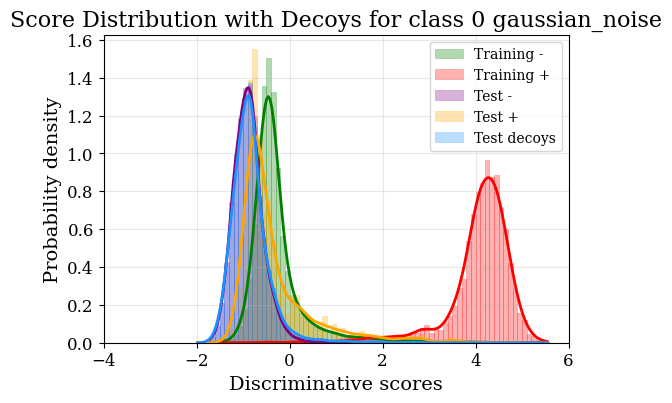

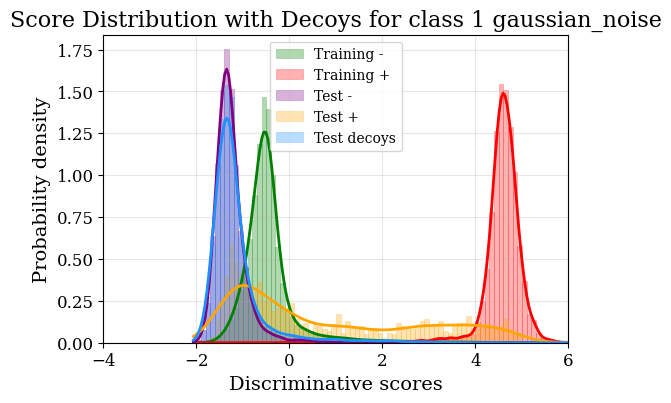

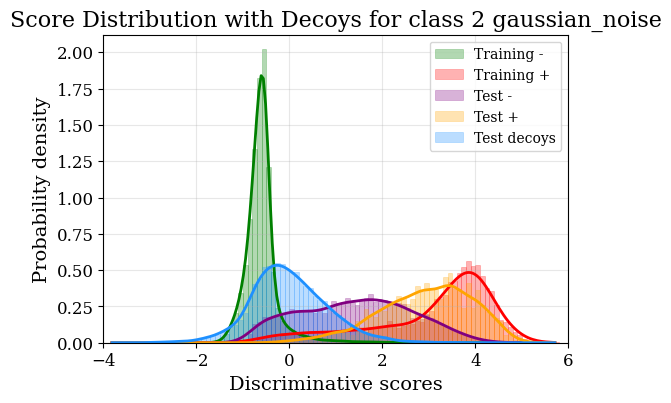

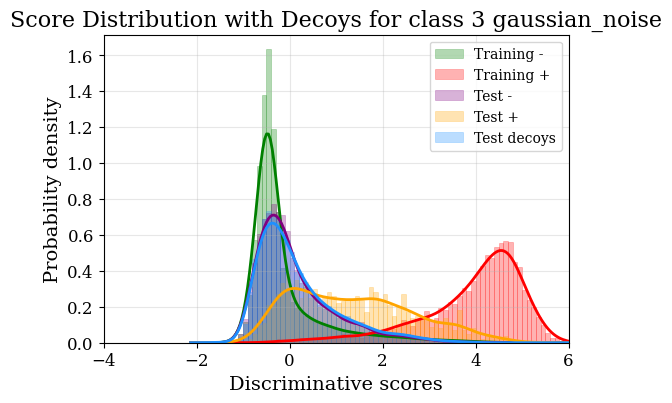

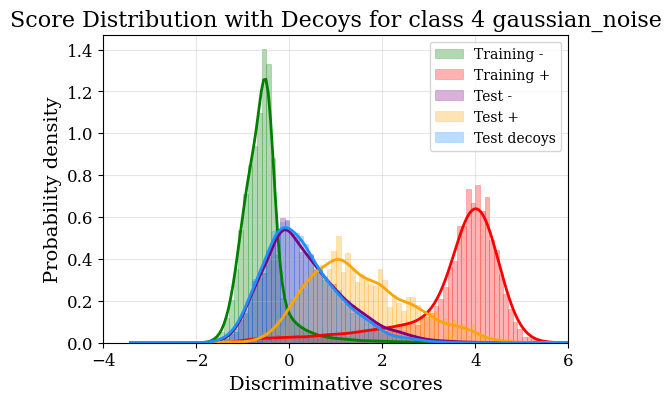

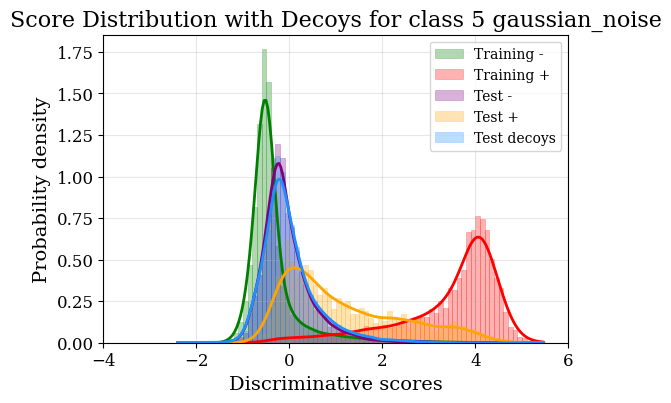

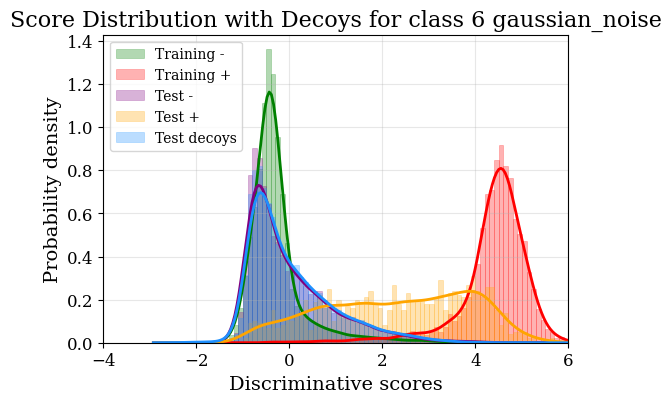

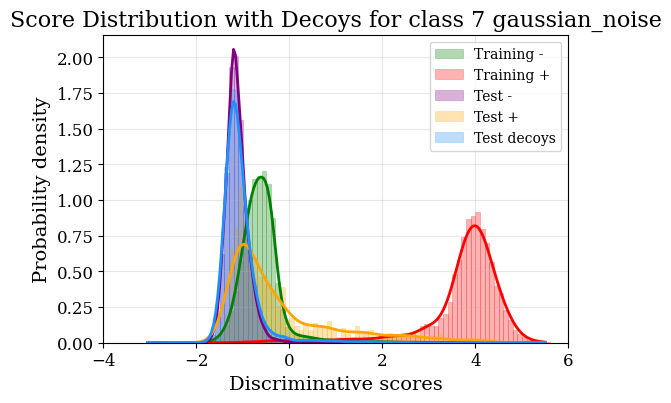

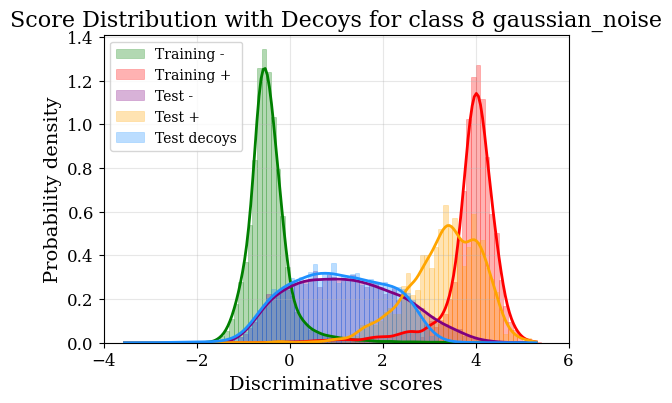

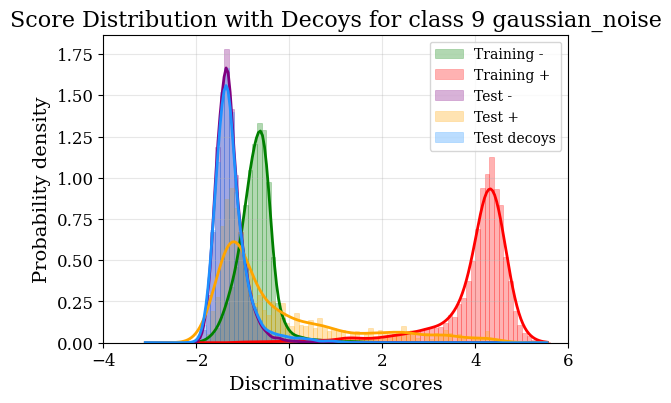

In [19]:
print(np.__version__)
np.set_printoptions(threshold=np.inf)

plt.rcParams.update({
    'font.size': 14,           # Base font size
    'axes.titlesize': 16,      # Axis titles
    'axes.labelsize': 14,      # Axis labels
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
    'legend.fontsize': 10,     # Legend (increased from 10)
    'figure.titlesize': 18     # Figure title
})


def plot_score_distribution_with_decoys(train_scores, train_labels, 
                                        test_scores, test_labels, 
                                        test_decoy_scores,
                                        filename="score_distribution_decoys", 
                                        title="Score Distribution with Decoys",
                                        xlim=(-10, 10), show_kde=False, class_id=None):
    
    plt.figure(figsize=(6, 4))  # Updated figure size
    
    # Convert to numpy arrays and flatten
    train_scores = np.array(train_scores).flatten()
    train_labels = np.array(train_labels).flatten()
    test_scores = np.array(test_scores).flatten()
    test_labels = np.array(test_labels).flatten()
    test_decoy_scores = np.array(test_decoy_scores).flatten()
    
    # Separate scores by class and dataset
    train_neg = train_scores[train_labels != class_id]
    train_pos = train_scores[train_labels == class_id]
    test_neg = test_scores[test_labels != class_id]
    test_pos = test_scores[test_labels == class_id]
    
    # Определяем бины как в примере
    bin_width = 0.1
    bins = np.arange(xlim[0], xlim[1] + bin_width, bin_width)
    
    # Plot histograms with stat="density" как в примере
    plt.hist(train_neg, bins=bins, density=True, color='green', 
             alpha=0.3, label='Training -', edgecolor='green', linewidth=0.5)
    plt.hist(train_pos, bins=bins, density=True, color='red', 
             alpha=0.3, label='Training +', edgecolor='red', linewidth=0.5)
    plt.hist(test_neg, bins=bins, density=True, color='purple', 
             alpha=0.3, label='Test -', edgecolor='purple', linewidth=0.5)
    plt.hist(test_pos, bins=bins, density=True, color='orange', 
             alpha=0.3, label='Test +', edgecolor='orange', linewidth=0.5)
    plt.hist(test_decoy_scores, bins=bins, density=True, color='dodgerblue', 
             alpha=0.3, label='Test decoys', edgecolor='dodgerblue', linewidth=0.5)
    
    # Add KDE curves if needed
    if show_kde:
        all_scores = np.concatenate([train_scores, test_scores, test_decoy_scores])
        x_range = np.linspace(all_scores.min(), all_scores.max(), 200)
        
        kde_bw = 0.2  # Параметр bandwidth как в примере
        
        if len(train_neg) > 1:
            try:
                kde_train_neg = stats.gaussian_kde(train_neg.flatten(), bw_method=kde_bw)
                plt.plot(x_range, kde_train_neg(x_range), color='green', 
                        linewidth=2, linestyle='-')
            except:
                pass
        
        if len(train_pos) > 1:
            try:
                kde_train_pos = stats.gaussian_kde(train_pos.flatten(), bw_method=kde_bw)
                plt.plot(x_range, kde_train_pos(x_range), color='red', 
                        linewidth=2, linestyle='-')
            except:
                pass
        
        if len(test_neg) > 1:
            try:
                kde_test_neg = stats.gaussian_kde(test_neg.flatten(), bw_method=kde_bw)
                plt.plot(x_range, kde_test_neg(x_range), color='purple', 
                        linewidth=2, linestyle='-')
            except:
                pass
        
        if len(test_pos) > 1:
            try:
                kde_test_pos = stats.gaussian_kde(test_pos.flatten(), bw_method=kde_bw)
                plt.plot(x_range, kde_test_pos(x_range), color='orange', 
                        linewidth=2, linestyle='-')
            except:
                pass
        
        if len(test_decoy_scores) > 1:
            try:
                kde_decoys = stats.gaussian_kde(test_decoy_scores.flatten(), bw_method=kde_bw)
                plt.plot(x_range, kde_decoys(x_range), color='dodgerblue', 
                        linewidth=2, linestyle='-')
            except:
                pass
    
    plt.xlabel('Discriminative scores')
    plt.ylabel('Probability density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Используем xlim для ограничения диапазона
    if xlim is not None:
        plt.xlim(xlim)
    
    plt.title(title)
    plt.show()


corruption_name = 'gaussian_noise'
model_scores, decoy_scores, labels = score_shift_flow.generate_decoys(
    test_corrupted_score_datasets[corruption_name], device=DEVICE)


for i in range(NUM_CLASSES):
    plot_score_distribution_with_decoys(train_scores[:, i], train_labels, 
                                        model_scores[:, i], labels, 
                                        decoy_scores[:, i],
                                        filename=f"score_distribution_decoys_mini_long_{i}", 
                                        title=f"Score Distribution with Decoys for class {i} {corruption_name}",
                                        xlim=(-4, 6), show_kde=True, class_id=i)


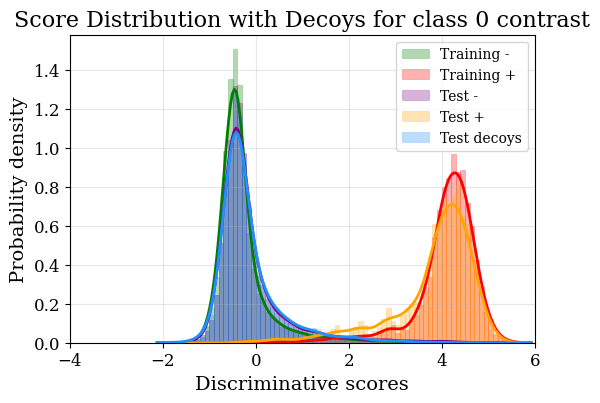

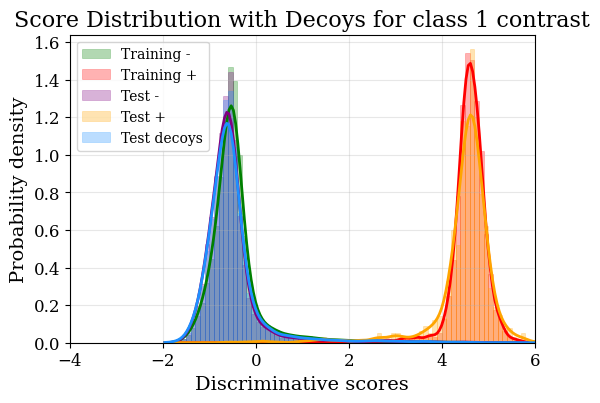

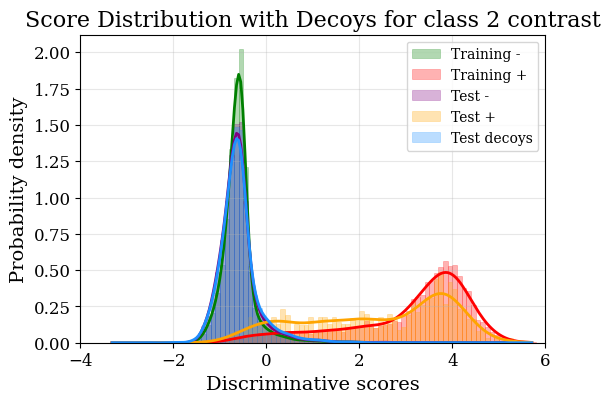

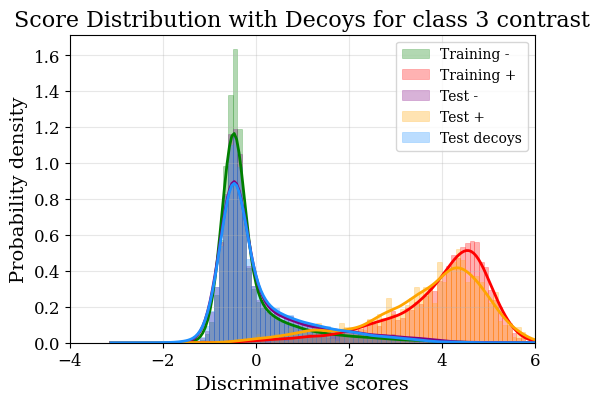

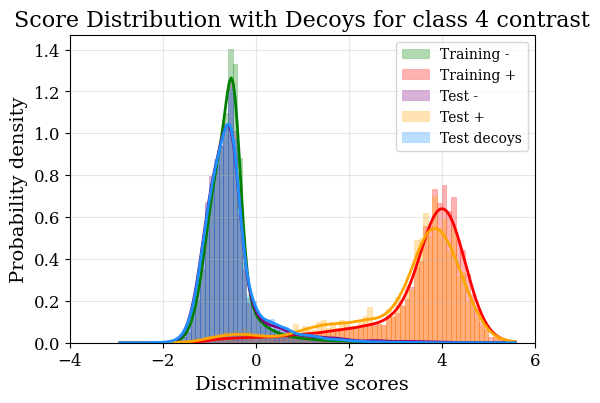

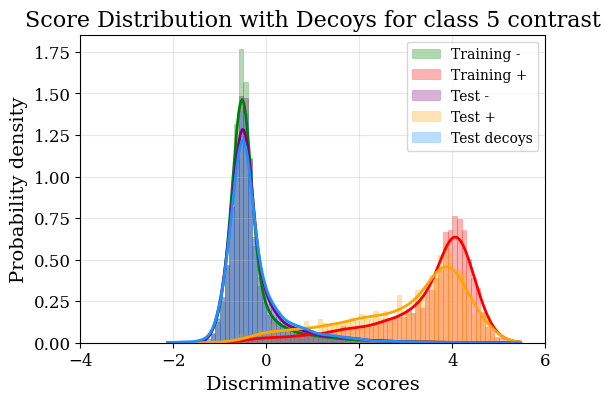

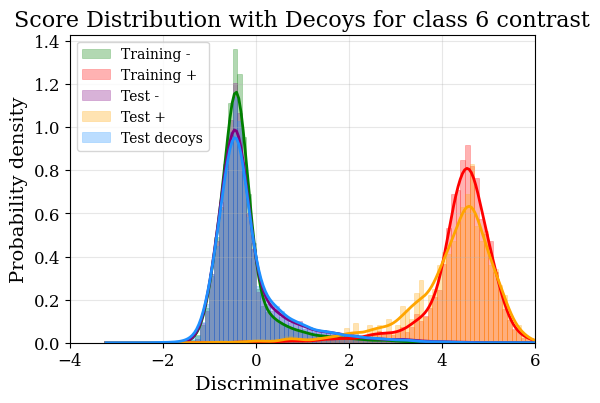

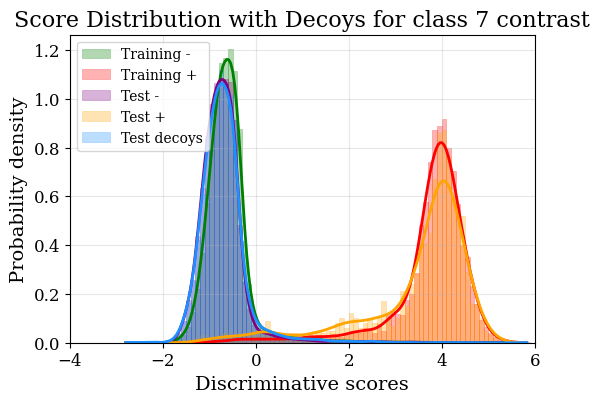

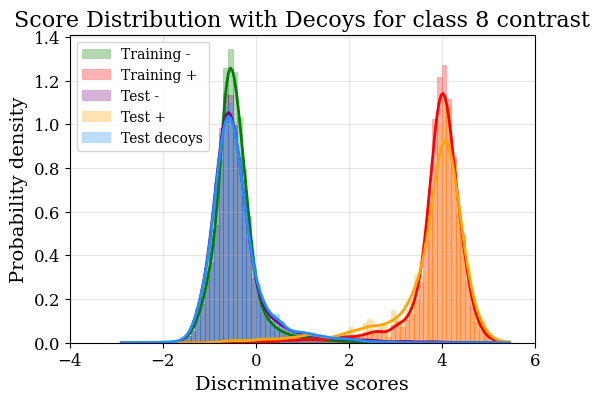

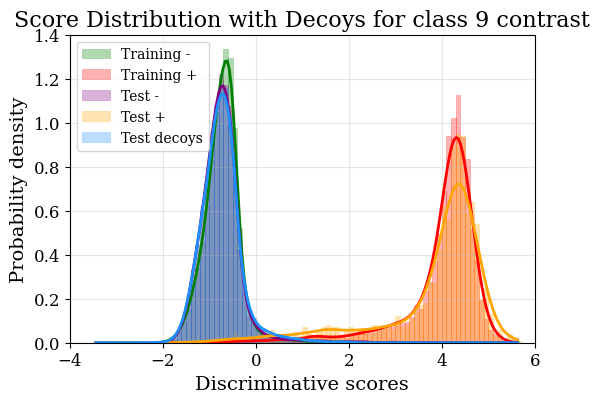

In [20]:
corruption_name = 'contrast'
model_scores, decoy_scores, labels = score_shift_flow.generate_decoys(
    test_corrupted_score_datasets[corruption_name], device=DEVICE)


for i in range(NUM_CLASSES):
    plot_score_distribution_with_decoys(train_scores[:, i], train_labels, 
                                        model_scores[:, i], labels, 
                                        decoy_scores[:, i],
                                        filename=f"score_distribution_decoys_mini_long_{i}", 
                                        title=f"Score Distribution with Decoys for class {i} {corruption_name}",
                                        xlim=(-4, 6), show_kde=True, class_id=i)

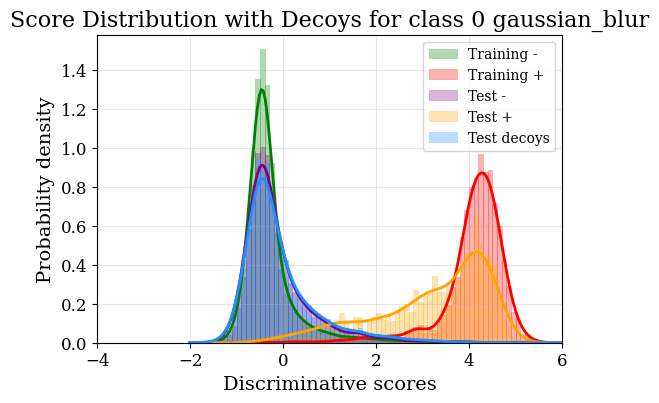

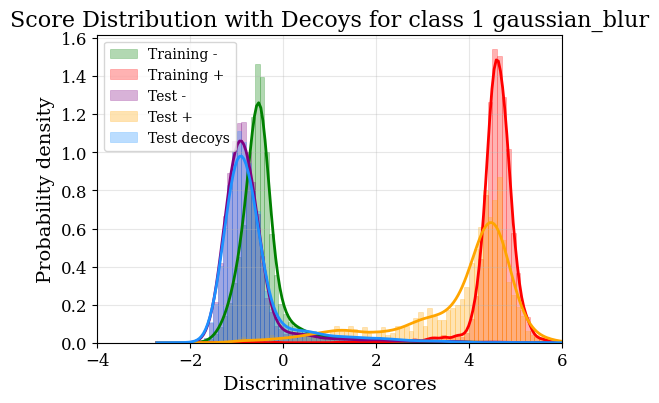

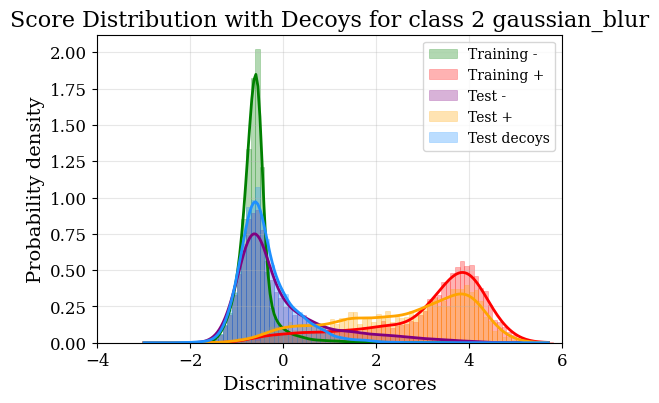

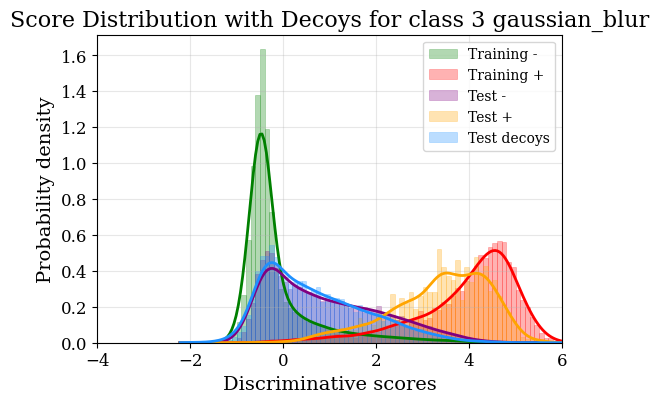

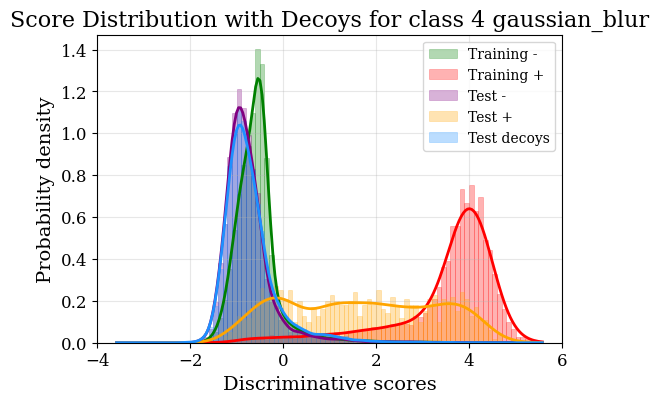

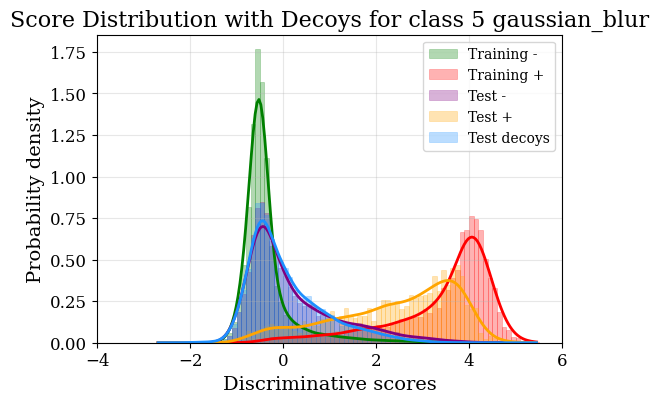

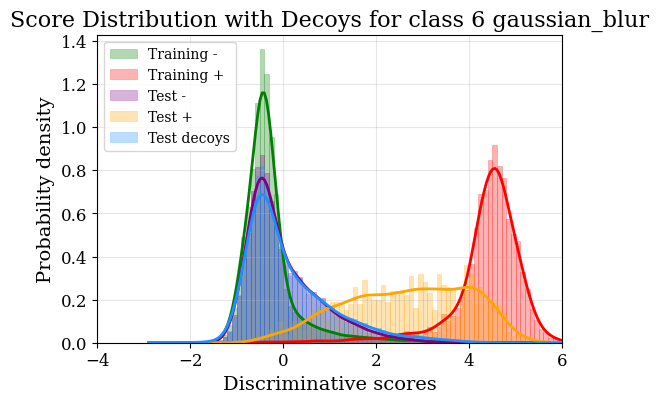

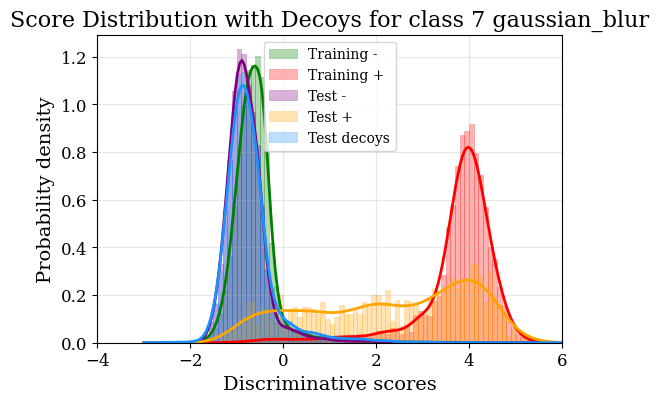

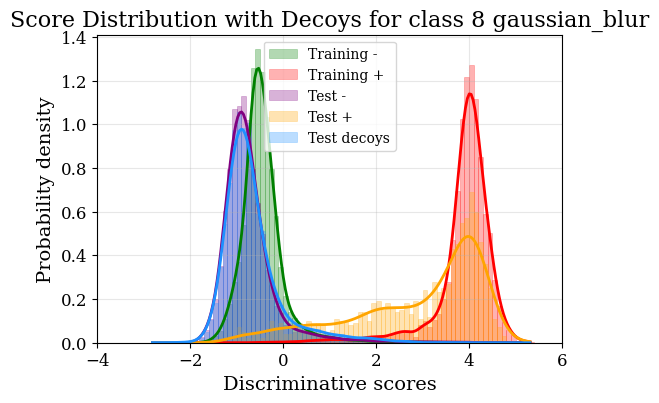

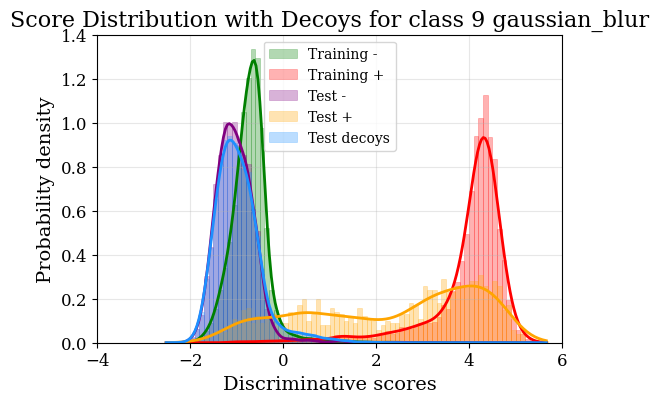

In [21]:
corruption_name = 'gaussian_blur'
model_scores, decoy_scores, labels = score_shift_flow.generate_decoys(
    test_corrupted_score_datasets[corruption_name], device=DEVICE)


for i in range(NUM_CLASSES):
    plot_score_distribution_with_decoys(train_scores[:, i], train_labels, 
                                        model_scores[:, i], labels, 
                                        decoy_scores[:, i],
                                        filename=f"score_distribution_decoys_mini_long_{i}", 
                                        title=f"Score Distribution with Decoys for class {i} {corruption_name}",
                                        xlim=(-4, 6), show_kde=True, class_id=i)

In [39]:
print("\n" + "="*80)
print("RUNNING FDR CONTROL  [Mix-Max]")
print("="*80)

all_fdr_results = {}   # corruption → DataFrame with q_values_mixmax

# Clean test set
print("\nProcessing: cifar10_test (clean)")
test_scores, test_decoys, test_labels = score_shift_flow.generate_decoys(
    test_score_dataset, device=DEVICE)
df_mixmax_clean = control_fdr_mixmax(test_scores, test_labels, test_decoys)
all_fdr_results['cifar10_test'] = df_mixmax_clean

# All corruptions
for corruption_name, score_dataset in test_corrupted_score_datasets.items():
    print(f"\nProcessing: {corruption_name}")
    model_scores, decoy_scores, labels = score_shift_flow.generate_decoys(
        score_dataset, device=DEVICE)
    df_mixmax = control_fdr_mixmax(model_scores, labels, decoy_scores)
    all_fdr_results[corruption_name] = df_mixmax

print("\n✓ FDR control complete")


RUNNING FDR CONTROL  [Mix-Max]

Processing: cifar10_test (clean)
  target_scores : [0.798, 6.296] mean=4.118
  null_scores   : [-3.111, 8.500] mean=-0.079
  mix_max_scores: [0.798, 8.500] mean=4.127
  target wins   : 0.967
  R_j: min=0.0000, max=1.0000, mean=0.1459
  fdr_values: min=0.0094, max=6.0000
  fdr_values first 5: [6.  3.  2.  1.5 1.2]
  q_values: min=0.0094, max=0.1459
  unique q_values: 686

Processing: gaussian_noise
  target_scores : [0.660, 5.658] mean=2.806
  null_scores   : [-3.817, 5.998] mean=0.769
  mix_max_scores: [0.660, 5.998] mean=2.829
  target wins   : 0.868
  R_j: min=0.0000, max=1.0000, mean=0.4940
  fdr_values: min=0.0270, max=1.0000
  fdr_values first 5: [1.         0.5        0.66666667 0.5        0.4       ]
  q_values: min=0.0270, max=0.4941
  unique q_values: 2158

Processing: shot_noise
  target_scores : [0.906, 6.281] mean=3.021
  null_scores   : [-4.005, 8.013] mean=0.711
  mix_max_scores: [0.910, 8.013] mean=3.048
  target wins   : 0.872
  R_j: min

In [46]:

print("\n" + "="*80)
print("GENERATING ACCURACY ESTIMATION PLOTS  [Mix-Max]")
print("="*80)

for corruption_name, df in all_fdr_results.items():
    plot_accuracy_estimation(
        df,
        q_value_column='q_values_mixmax',
        method_name='Mix-Max',
        corruption_name=corruption_name,
        save_dir='figures/accuracy'
    )

print("\n✓ Accuracy plots saved to figures/accuracy/")


GENERATING ACCURACY ESTIMATION PLOTS  [Mix-Max]
  ✓ cifar10_test: π₀=0.000  best_q=0.078  n_accepted=9791/10000  est_acc=0.903  true_acc=0.894  error=0.009
  ✓ gaussian_noise: π₀=0.000  best_q=0.375  n_accepted=9586/10000  est_acc=0.600  true_acc=0.367  error=0.233
  ✓ shot_noise: π₀=0.000  best_q=0.329  n_accepted=9385/10000  est_acc=0.630  true_acc=0.498  error=0.132
  ✓ impulse_noise: π₀=0.000  best_q=0.250  n_accepted=8987/10000  est_acc=0.674  true_acc=0.634  error=0.040
  ✓ defocus_blur: π₀=0.000  best_q=0.150  n_accepted=9766/10000  est_acc=0.831  true_acc=0.816  error=0.014
  ✓ glass_blur: π₀=0.000  best_q=0.351  n_accepted=9427/10000  est_acc=0.612  true_acc=0.368  error=0.244
  ✓ motion_blur: π₀=0.000  best_q=0.259  n_accepted=9380/10000  est_acc=0.695  true_acc=0.585  error=0.110
  ✓ zoom_blur: π₀=0.000  best_q=0.248  n_accepted=9661/10000  est_acc=0.726  true_acc=0.691  error=0.035
  ✓ snow: π₀=0.000  best_q=0.167  n_accepted=9612/10000  est_acc=0.800  true_acc=0.739  erro

In [47]:
print("\n" + "="*80)
print("GENERATING ACCURACY ESTIMATION PLOTS  [Mix-Max]")
print("="*80)

summary_results = []

for corruption_name, df in all_fdr_results.items():
    df_method, pi0 = plot_accuracy_estimation(
        df,
        q_value_column='q_values_mixmax',
        method_name='Mix-Max',
        corruption_name=corruption_name,
        save_dir='figures/accuracy'
    )
    
    if df_method is not None and len(df_method) > 0:
        best_idx = df_method['Accuracy_est'].idxmax()
        summary_results.append({
            'corruption'    : corruption_name,
            'est_acc'       : df_method.loc[best_idx, 'Accuracy_est'],
            'true_acc'      : df_method.loc[best_idx, 'Accuracy_true_at_threshold'],
            'error'         : df_method.loc[best_idx, 'error_at_threshold'],
            'best_q'        : df_method.loc[best_idx, 'q_value_method'],
            'n_accepted'    : int(df_method.loc[best_idx, 'n_discoveries']),
            'n_total'       : len(df),
            'frac_accepted' : df_method.loc[best_idx, 'n_discoveries'] / len(df),
        })

summary_df = pd.DataFrame(summary_results)
print(f"\n{'='*80}")
print(f"SUMMARY")
print(f"{'='*80}")
print(f"\n{'Corruption':<25} {'Est':>7} {'True':>7} "
      f"{'Error':>7} {'Best_q':>8} {'Accept%':>9}")
print("-" * 70)
for _, row in summary_df.iterrows():
    print(f"  {row['corruption']:<23} "
          f"{row['est_acc']:7.3f} "
          f"{row['true_acc']:7.3f} "
          f"{row['error']:7.3f} "
          f"{row['best_q']:8.3f} "
          f"{row['frac_accepted']*100:8.1f}%")

print(f"\n  Mean Error : {summary_df['error'].mean():.4f}")
print(f"  Mean Accept: {summary_df['frac_accepted'].mean()*100:.1f}%")

summary_df.to_csv('figures/comparison/mixmax_summary.csv', index=False)
print("\n✓ Summary saved to figures/comparison/mixmax_summary.csv")


GENERATING ACCURACY ESTIMATION PLOTS  [Mix-Max]
  ✓ cifar10_test: π₀=0.000  best_q=0.078  n_accepted=9791/10000  est_acc=0.903  true_acc=0.894  error=0.009
  ✓ gaussian_noise: π₀=0.000  best_q=0.375  n_accepted=9586/10000  est_acc=0.600  true_acc=0.367  error=0.233
  ✓ shot_noise: π₀=0.000  best_q=0.329  n_accepted=9385/10000  est_acc=0.630  true_acc=0.498  error=0.132
  ✓ impulse_noise: π₀=0.000  best_q=0.250  n_accepted=8987/10000  est_acc=0.674  true_acc=0.634  error=0.040
  ✓ defocus_blur: π₀=0.000  best_q=0.150  n_accepted=9766/10000  est_acc=0.831  true_acc=0.816  error=0.014
  ✓ glass_blur: π₀=0.000  best_q=0.351  n_accepted=9427/10000  est_acc=0.612  true_acc=0.368  error=0.244
  ✓ motion_blur: π₀=0.000  best_q=0.259  n_accepted=9380/10000  est_acc=0.695  true_acc=0.585  error=0.110
  ✓ zoom_blur: π₀=0.000  best_q=0.248  n_accepted=9661/10000  est_acc=0.726  true_acc=0.691  error=0.035
  ✓ snow: π₀=0.000  best_q=0.167  n_accepted=9612/10000  est_acc=0.800  true_acc=0.739  erro

In [48]:
print("\n" + "="*80)
print("GENERATING FDR CURVE PLOTS")
print("="*80)

for corruption_name, df in all_fdr_results.items():
    plot_fdr_curve(df, corruption_name, save_dir='figures/fdr')

print("\n✓ FDR curve plots saved to figures/fdr/")


GENERATING FDR CURVE PLOTS
  ✓ cifar10_test
  ✓ gaussian_noise
  ✓ shot_noise
  ✓ impulse_noise
  ✓ defocus_blur
  ✓ glass_blur
  ✓ motion_blur
  ✓ zoom_blur
  ✓ snow
  ✓ frost
  ✓ fog
  ✓ brightness
  ✓ contrast
  ✓ elastic_transform
  ✓ pixelate
  ✓ jpeg_compression
  ✓ speckle_noise
  ✓ gaussian_blur
  ✓ spatter
  ✓ saturate

✓ FDR curve plots saved to figures/fdr/


In [49]:
print("\n" + "="*80)
print("RUNNING EVALUATIONS")
print("="*80)

# Source logits (clean train) — computed once for baselines
source_logits, source_decoy_scores, source_labels = score_shift_flow.generate_decoys(
    train_score_dataset, device=DEVICE)
source_logits_t  = torch.tensor(source_logits).to(DEVICE)
source_labels_t  = torch.tensor(source_labels).to(DEVICE)
temp = calibration_temp(source_logits_t, source_labels_t)

all_results = []

for corruption_name, score_dataset in test_corrupted_score_datasets.items():
    print(f"\nProcessing: {corruption_name}")
    model_scores, decoy_scores, labels = score_shift_flow.generate_decoys(
        score_dataset, device=DEVICE)

    target_logits_t = torch.tensor(model_scores).to(DEVICE)
    target_labels_t = torch.tensor(labels).to(DEVICE)

    # True accuracy on FULL dataset (for baselines comparison)
    true_acc_full = (target_logits_t.argmax(1) == target_labels_t).float().mean().item()

    # ── Mix-Max ───────────────────────────────────────────────────────────
    df_mixmax = control_fdr_mixmax(model_scores, labels, decoy_scores)
    pi0       = 0.0
    df_curve  = compute_method_estimation_curve(df_mixmax, 'q_values_mixmax', pi0)

    if len(df_curve) > 0:
        best_idx      = df_curve['Accuracy_est'].idxmax()
        mixmax_est    = df_curve.loc[best_idx, 'Accuracy_est']
        # True accuracy at the SAME threshold (honest comparison)
        mixmax_true_at_thresh = df_curve.loc[best_idx, 'Accuracy_true_at_threshold']
        mixmax_error  = df_curve.loc[best_idx, 'error_at_threshold']
        best_q        = df_curve.loc[best_idx, 'q_value_method']
        n_accepted    = int(df_curve.loc[best_idx, 'n_discoveries'])
    else:
        mixmax_est            = 0.0
        mixmax_true_at_thresh = 0.0
        mixmax_error          = 0.0
        best_q                = np.nan
        n_accepted            = 0

    all_results.append({
        'corruption'          : corruption_name,
        'method'              : 'Mix-Max',
        'estimated_accuracy'  : mixmax_est,
        # For Mix-Max: true_accuracy = true acc at best threshold
        'true_accuracy'       : mixmax_true_at_thresh,
        # Also store full-dataset true acc for reference
        'true_accuracy_full'  : true_acc_full,
        'error'               : mixmax_error,
        'best_q'              : best_q,
        'n_accepted'          : n_accepted,
        'n_total'             : len(labels),
        'frac_accepted'       : n_accepted / len(labels),
    })
    print(f"  Mix-Max: est={mixmax_est:.3f}  "
          f"true@thresh={mixmax_true_at_thresh:.3f}  "
          f"true_full={true_acc_full:.3f}  "
          f"error={mixmax_error:.3f}  "
          f"q*={best_q:.3f}  "
          f"accepted={n_accepted}/{len(labels)}")

    # ── Baseline methods (compare against full-dataset true acc) ──────────
    scaled_source = source_logits_t / temp
    scaled_target = target_logits_t / temp

    for method_name, method_func in BASELINE_METHODS.items():
        try:
            estimate = method_func(scaled_source, source_labels_t, scaled_target)
            error    = abs(estimate - true_acc_full)
            all_results.append({
                'corruption'         : corruption_name,
                'method'             : method_name,
                'estimated_accuracy' : estimate,
                'true_accuracy'      : true_acc_full,
                'true_accuracy_full' : true_acc_full,
                'error'              : error,
                'best_q'             : np.nan,
                'n_accepted'         : len(labels),
                'n_total'            : len(labels),
                'frac_accepted'      : 1.0,
            })
            print(f"  {method_name}: est={estimate:.3f}  "
                  f"true={true_acc_full:.3f}  error={error:.3f}")
        except Exception as e:
            print(f"  {method_name}: FAILED ({e})")

results_df = pd.DataFrame(all_results)
print("\n✓ All evaluations complete")


print("\n" + "="*80)
print("STATISTICAL ANALYSIS")
print("="*80)

# ── Note about comparison ─────────────────────────────────────────────────
print("""
NOTE on comparison:
  Mix-Max  → error = |est_acc - true_acc_at_best_threshold|
             (true_acc computed on ACCEPTED samples only)
  Baselines → error = |est_acc - true_acc_full_dataset|
             (true_acc computed on ALL samples)
  These measure different things — Mix-Max selects a subset,
  baselines estimate accuracy on the whole dataset.
""")

stats_data = []
for method in results_df['method'].unique():
    df_m   = results_df[results_df['method'] == method]
    errors = df_m['estimated_accuracy'] - df_m['true_accuracy']
    abs_e  = np.abs(errors)

    is_mixmax = method == 'Mix-Max'
    stats_data.append({
        'Method'       : method,
        'MAE'          : abs_e.mean(),
        'RMSE'         : np.sqrt((errors**2).mean()),
        'Mean Bias'    : errors.mean(),
        'Std Dev'      : errors.std(),
        'Max Error'    : abs_e.max(),
        # For Mix-Max: also report avg fraction accepted
        'Avg Accept %' : f"{df_m['frac_accepted'].mean()*100:.1f}%" \
                         if is_mixmax else "100.0%",
        'True Acc Type': 'at threshold' if is_mixmax else 'full dataset',
    })

stats_df = pd.DataFrame(stats_data).sort_values('MAE')

print("\nPerformance Statistics:")
print(stats_df.to_string(index=False))

# ── Separate summary for Mix-Max ──────────────────────────────────────────
mm_df = results_df[results_df['method'] == 'Mix-Max']
print(f"\nMix-Max detailed:")
print(f"  Mean est_acc       : {mm_df['estimated_accuracy'].mean():.3f}")
print(f"  Mean true@thresh   : {mm_df['true_accuracy'].mean():.3f}")
print(f"  Mean true_full     : {mm_df['true_accuracy_full'].mean():.3f}")
print(f"  MAE vs thresh      : {mm_df['error'].mean():.4f}")
print(f"  MAE vs full        : {(mm_df['estimated_accuracy'] - mm_df['true_accuracy_full']).abs().mean():.4f}")
print(f"  Avg accepted       : {mm_df['frac_accepted'].mean()*100:.1f}%")
print(f"  Avg best q*        : {mm_df['best_q'].mean():.3f}")

stats_df.to_csv('figures/comparison/statistics.csv', index=False)
results_df.to_csv('figures/comparison/all_results.csv', index=False)
print("\n✓ Statistics saved to figures/comparison/statistics.csv")
print("✓ Results saved to figures/comparison/all_results.csv")


RUNNING EVALUATIONS

Processing: gaussian_noise
  target_scores : [0.660, 5.658] mean=2.806
  null_scores   : [-4.051, 6.672] mean=0.764
  mix_max_scores: [0.660, 6.672] mean=2.829
  target wins   : 0.874
  R_j: min=0.0000, max=1.0000, mean=0.4965
  fdr_values: min=0.0256, max=2.0000
  fdr_values first 5: [2.         1.         0.66666667 0.5        0.4       ]
  q_values: min=0.0256, max=0.4966
  unique q_values: 2194
  Mix-Max: est=0.599  true@thresh=0.367  true_full=0.371  error=0.232  q*=0.374  accepted=9557/10000
  ATC: est=0.459  true=0.371  error=0.088
  ATC-NE: est=0.440  true=0.371  error=0.069
  AC: est=0.695  true=0.371  error=0.324
  DOC: est=0.676  true=0.371  error=0.305
  COT: est=0.443  true=0.371  error=0.072

Processing: shot_noise
  target_scores : [0.906, 6.281] mean=3.021
  null_scores   : [-3.430, 6.964] mean=0.695
  mix_max_scores: [0.906, 6.964] mean=3.046
  target wins   : 0.875
  R_j: min=0.0000, max=1.0000, mean=0.4288
  fdr_values: min=0.0320, max=1.5000
  

In [50]:
print("\n" + "="*80)
print("STATISTICAL ANALYSIS")
print("="*80)

print("""
NOTE on comparison:
  Mix-Max  → 'vs threshold' error = |est_acc - true_acc_at_best_threshold|
             (true_acc computed on ACCEPTED samples only)
  All      → 'vs full'     error = |est_acc - true_acc_full_dataset|
             (true_acc computed on ALL samples)
""")

# ── Collect errors ────────────────────────────────────────────────────────
mae_vs_full      = {}   # all methods vs full dataset true acc
mae_vs_threshold = {}   # Mix-Max only vs true acc at threshold

for method in results_df['method'].unique():
    df_m = results_df[results_df['method'] == method]

    # vs full dataset
    errors_full = np.abs(df_m['estimated_accuracy'] - df_m['true_accuracy_full'])
    mae_vs_full[method] = errors_full.values

    # vs threshold (Mix-Max only)
    if method == 'Mix-Max':
        errors_thresh = np.abs(df_m['estimated_accuracy'] - df_m['true_accuracy'])
        mae_vs_threshold[method] = errors_thresh.values

# ── Print table 1: MAE vs full dataset true accuracy ─────────────────────
print("\nMean Absolute Error (MAE) vs True Accuracy (full dataset):")
print("-" * 60)

# Sort by MAE
sorted_methods = sorted(mae_vs_full.items(), key=lambda x: x[1].mean())
for method, errors in sorted_methods:
    label = 'Mix-Max (est)' if method == 'Mix-Max' else method
    print(f"  {label:<25}: {errors.mean():.4f} ± {errors.std():.4f}")

# ── Print table 2: MAE vs true accuracy at threshold (Mix-Max only) ──────
print("\nMean Absolute Error (MAE) vs True Accuracy at Threshold:")
print("-" * 60)
for method, errors in mae_vs_threshold.items():
    label = 'Mix-Max (at threshold)'
    print(f"  {label:<25}: {errors.mean():.4f} ± {errors.std():.4f}")

# ── Full stats table ──────────────────────────────────────────────────────
print("\nFull Performance Statistics:")
print("-" * 90)

stats_data = []
for method in results_df['method'].unique():
    df_m         = results_df[results_df['method'] == method]
    errors_full  = df_m['estimated_accuracy'].values - df_m['true_accuracy_full'].values
    abs_full     = np.abs(errors_full)

    row = {
        'Method'            : method,
        'MAE (vs full)'     : abs_full.mean(),
        'Std (vs full)'     : abs_full.std(),
        'RMSE (vs full)'    : np.sqrt((errors_full**2).mean()),
        'Bias (vs full)'    : errors_full.mean(),
        'Max (vs full)'     : abs_full.max(),
        'Accept %'          : f"{df_m['frac_accepted'].mean()*100:.1f}%",
    }

    if method == 'Mix-Max':
        errors_thresh = df_m['estimated_accuracy'].values - df_m['true_accuracy'].values
        abs_thresh    = np.abs(errors_thresh)
        row.update({
            'MAE (vs thresh)'  : abs_thresh.mean(),
            'Std (vs thresh)'  : abs_thresh.std(),
            'RMSE (vs thresh)' : np.sqrt((errors_thresh**2).mean()),
            'Bias (vs thresh)' : errors_thresh.mean(),
        })
    else:
        row.update({
            'MAE (vs thresh)'  : np.nan,
            'Std (vs thresh)'  : np.nan,
            'RMSE (vs thresh)' : np.nan,
            'Bias (vs thresh)' : np.nan,
        })

    stats_data.append(row)

stats_df = pd.DataFrame(stats_data).sort_values('MAE (vs full)')

# Print nicely
col_order = [
    'Method',
    'MAE (vs full)', 'Std (vs full)', 'Bias (vs full)', 'Max (vs full)',
    'MAE (vs thresh)', 'Std (vs thresh)',
    'Accept %',
]
print(stats_df[col_order].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# ── Save ──────────────────────────────────────────────────────────────────
stats_df.to_csv('figures/comparison/statistics.csv', index=False)
results_df.to_csv('figures/comparison/all_results.csv', index=False)
print("\n✓ Statistics saved")

# ── Per-corruption breakdown for Mix-Max ──────────────────────────────────
print("\nMix-Max per-corruption breakdown:")
print(f"{'Corruption':<25} {'Est':>7} {'True@D':>8} "
      f"{'True_full':>10} {'Err@D':>7} {'Err_full':>9} "
      f"{'q*':>6} {'Accept%':>8}")
print("-" * 85)

mm_df = results_df[results_df['method'] == 'Mix-Max'].copy()
mm_df['err_full'] = np.abs(mm_df['estimated_accuracy'] - mm_df['true_accuracy_full'])

for _, row in mm_df.sort_values('true_accuracy_full').iterrows():
    print(f"  {row['corruption']:<23} "
          f"{row['estimated_accuracy']:7.3f} "
          f"{row['true_accuracy']:8.3f} "
          f"{row['true_accuracy_full']:10.3f} "
          f"{row['error']:7.3f} "
          f"{row['err_full']:9.3f} "
          f"{row['best_q']:6.3f} "
          f"{row['frac_accepted']*100:7.1f}%")

print(f"\n  {'MEAN':<23} "
      f"{mm_df['estimated_accuracy'].mean():7.3f} "
      f"{mm_df['true_accuracy'].mean():8.3f} "
      f"{mm_df['true_accuracy_full'].mean():10.3f} "
      f"{mm_df['error'].mean():7.3f} "
      f"{mm_df['err_full'].mean():9.3f} "
      f"{'':6} "
      f"{mm_df['frac_accepted'].mean()*100:7.1f}%")


STATISTICAL ANALYSIS

NOTE on comparison:
  Mix-Max  → 'vs threshold' error = |est_acc - true_acc_at_best_threshold|
             (true_acc computed on ACCEPTED samples only)
  All      → 'vs full'     error = |est_acc - true_acc_full_dataset|
             (true_acc computed on ALL samples)


Mean Absolute Error (MAE) vs True Accuracy (full dataset):
------------------------------------------------------------
  ATC-NE                   : 0.0293 ± 0.0293
  COT                      : 0.0321 ± 0.0256
  ATC                      : 0.0423 ± 0.0377
  Mix-Max (est)            : 0.0613 ± 0.0675
  DOC                      : 0.1214 ± 0.0878
  AC                       : 0.1406 ± 0.0878

Mean Absolute Error (MAE) vs True Accuracy at Threshold:
------------------------------------------------------------
  Mix-Max (at threshold)   : 0.0714 ± 0.0673

Full Performance Statistics:
------------------------------------------------------------------------------------------
 Method  MAE (vs full)  Std (v

## 10. Generate Comparison Plots

In [43]:
print("\n" + "="*80)
print("GENERATING COMPARISON PLOTS")
print("="*80)

print("\n1. Per-Corruption Comparisons")
for corruption in corruptions_to_test:
    if corruption in results_df['corruption'].values:
        plot_method_comparison(results_df, corruption)

print("\n2. Overall Comparison")
mae_df = plot_overall_comparison(results_df)

print("\n3. Scatter Plots (Estimated vs True Accuracy)")
plot_scatter_estimated_vs_true(results_df, save_dir='figures/comparison')

results_df.to_csv('figures/comparison/all_results.csv', index=False)
print("\n✓ Results saved to figures/comparison/all_results.csv")


GENERATING COMPARISON PLOTS

1. Per-Corruption Comparisons
  ✓ gaussian_noise
  ✓ shot_noise
  ✓ impulse_noise
  ✓ defocus_blur
  ✓ glass_blur
  ✓ motion_blur
  ✓ zoom_blur
  ✓ snow
  ✓ frost
  ✓ fog
  ✓ brightness
  ✓ contrast
  ✓ elastic_transform
  ✓ pixelate
  ✓ jpeg_compression
  ✓ speckle_noise
  ✓ gaussian_blur
  ✓ spatter
  ✓ saturate

2. Overall Comparison

✓ Overall comparison plot saved

Mean Absolute Error (MAE) by Method:
 Method      MAE
 ATC-NE 0.029300
    COT 0.032058
    ATC 0.042337
Mix-Max 0.061579
    DOC 0.121373
     AC 0.140574

3. Scatter Plots (Estimated vs True Accuracy)
✓ Scatter plots saved

✓ Results saved to figures/comparison/all_results.csv


## 11. Statistical Analysis

In [51]:
print("\n" + "="*80)
print("STATISTICAL ANALYSIS")
print("="*80)

stats_data = []
for method in results_df['method'].unique():
    df_m   = results_df[results_df['method'] == method]
    errors = df_m['estimated_accuracy'] - df_m['true_accuracy']
    abs_e  = np.abs(errors)
    stats_data.append({
        'Method'    : method,
        'MAE'       : abs_e.mean(),
        'RMSE'      : np.sqrt((errors**2).mean()),
        'Mean Bias' : errors.mean(),
        'Std Dev'   : errors.std(),
        'Max Error' : abs_e.max(),
    })

stats_df = pd.DataFrame(stats_data).sort_values('MAE')
print("\nPerformance Statistics:")
print(stats_df.to_string(index=False))

stats_df.to_csv('figures/comparison/statistics.csv', index=False)
print("\n✓ Statistics saved to figures/comparison/statistics.csv")


STATISTICAL ANALYSIS

Performance Statistics:
 Method      MAE     RMSE  Mean Bias  Std Dev  Max Error
 ATC-NE 0.029300 0.041408   0.021342 0.036457   0.102300
    COT 0.032058 0.041016   0.030892 0.027722   0.095823
    ATC 0.042337 0.056704   0.039568 0.041730   0.155400
Mix-Max 0.071353 0.098076   0.071353 0.069133   0.237300
    DOC 0.121373 0.149795   0.121373 0.090195   0.331538
     AC 0.140574 0.165735   0.140574 0.090195   0.350739

✓ Statistics saved to figures/comparison/statistics.csv


✓ Helper functions loaded

RUNNING EVALUATIONS


Processing corruptions:   0%|          | 0/19 [00:00<?, ?it/s]

  target_scores : [0.660, 5.658] mean=2.806
  null_scores   : [-3.776, 7.546] mean=0.767
  mix_max_scores: [0.660, 7.546] mean=2.828
  target wins   : 0.872
  R_j: min=0.0000, max=1.0000, mean=0.4955
  fdr_values: min=0.0309, max=1.0000
  fdr_values first 5: [1.         0.5        0.33333333 0.25       0.2       ]
  q_values: min=0.0309, max=0.4957
  unique q_values: 2182


Processing corruptions:   5%|▌         | 1/19 [00:00<00:16,  1.06it/s]

  target_scores : [0.906, 6.281] mean=3.021
  null_scores   : [-4.379, 9.076] mean=0.700
  mix_max_scores: [0.906, 9.076] mean=3.045
  target wins   : 0.872
  R_j: min=0.0000, max=1.0000, mean=0.4325
  fdr_values: min=0.0250, max=2.0000
  fdr_values first 5: [2.  1.5 1.  1.  0.8]
  q_values: min=0.0250, max=0.4326
  unique q_values: 2077


...

  target_scores : [0.632, 6.308] mean=3.603
  null_scores   : [-3.920, 6.435] mean=0.193
  mix_max_scores: [0.632, 6.435] mean=3.620
  target wins   : 0.929
  R_j: min=0.0000, max=1.0000, mean=0.2723
  fdr_values: min=0.0206, max=1.0000
  fdr_values first 5: [1.         0.5        0.66666667 0.5        0.4       ]
  q_values: min=0.0206, max=0.2723
  unique q_values: 1242


Processing corruptions:  95%|█████████▍| 18/19 [00:15<00:00,  1.15it/s]

  target_scores : [0.894, 6.287] mean=4.103
  null_scores   : [-3.576, 8.411] mean=-0.092
  mix_max_scores: [0.927, 8.411] mean=4.111
  target wins   : 0.968
  R_j: min=0.0000, max=1.0000, mean=0.1348
  fdr_values: min=0.0095, max=1.0000
  fdr_values first 5: [1.         0.5        0.33333333 0.5        0.4       ]
  q_values: min=0.0095, max=0.1348
  unique q_values: 666


Processing corruptions: 100%|██████████| 19/19 [00:16<00:00,  1.15it/s]



✓ Processed 19 corruptions

COMPUTING ERRORS

Mean Absolute Error (MAE) vs True Accuracy (full dataset):
------------------------------------------------------------
  ATC-NE                   : 0.0293 ± 0.0301
  COT                      : 0.0321 ± 0.0263
  ATC                      : 0.0423 ± 0.0388
  Mix-Max (ours)           : 0.0630 ± 0.0692
  DOC                      : 0.1214 ± 0.0902
  AC                       : 0.1406 ± 0.0902

Mean Absolute Error (MAE) vs True Accuracy at Threshold:
------------------------------------------------------------
  Mix-Max (at threshold)   : 0.0739 ± 0.0694

CREATING VISUALIZATIONS


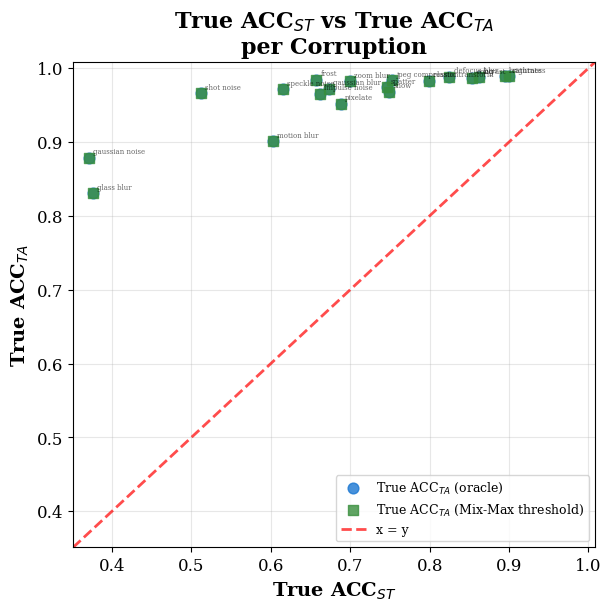

✓ scatter_true_vs_best.png/pdf


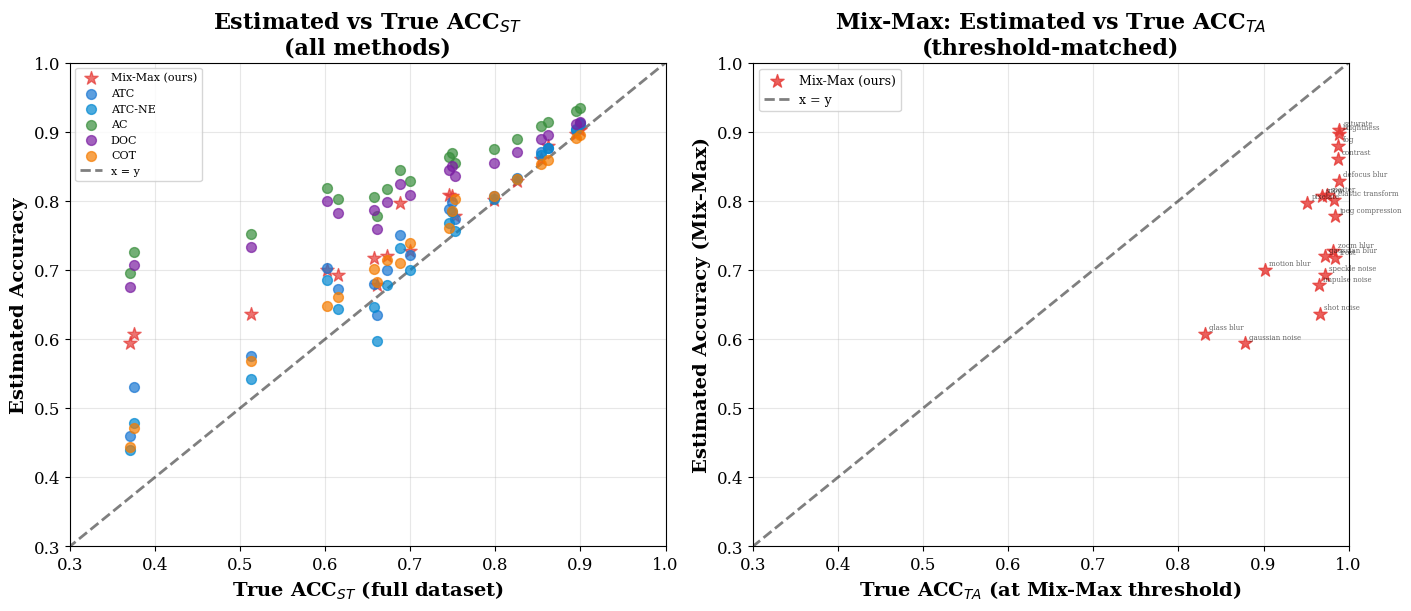

✓ scatter_est_vs_true_comparison.png/pdf


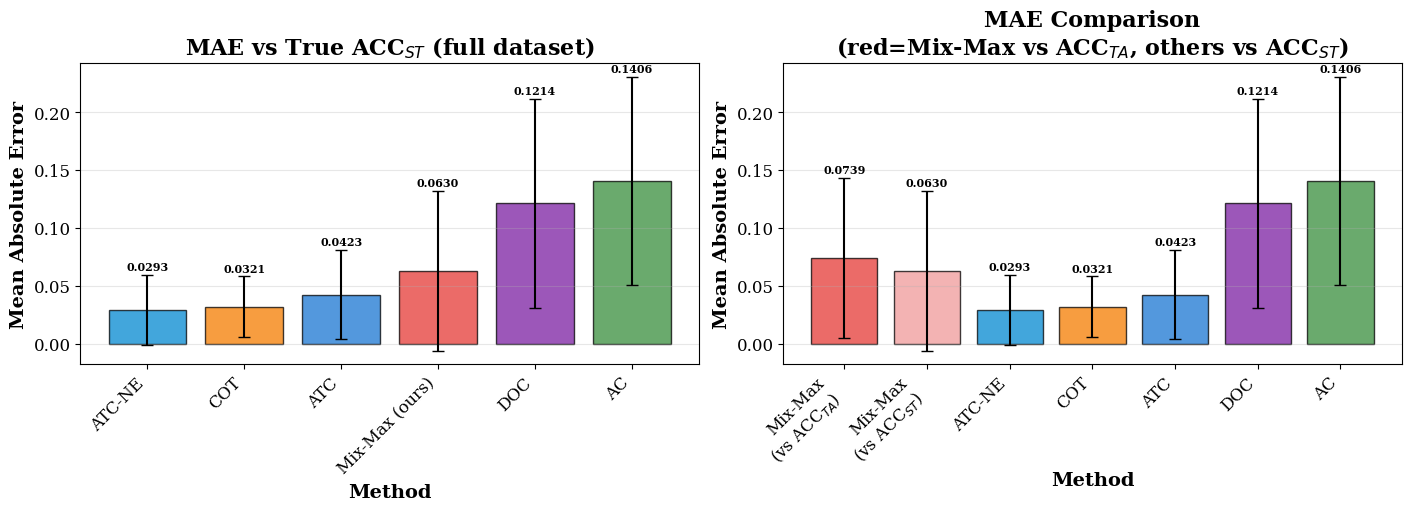

✓ mean_error_comparison.png/pdf

SUMMARY STATISTICS

1. Accuracy Statistics:
   Mean true ACC_ST          : 0.6968 ± 0.1545
   Mean true ACC_TA (oracle) : 0.9607 ± 0.0432
   Mean true ACC_TA (thresh) : 0.9607 ± 0.0432

2. Mix-Max Performance:
   Mean est acc              : 0.7598
   MAE vs ACC_ST (full)      : 0.0630 ± 0.0692
   MAE vs ACC_TA (threshold) : 0.0739 ± 0.0694
   Avg fraction accepted     : 95.7%
   Avg best q*               : 0.208

3. Baseline MAE vs ACC_ST:
   ATC       : 0.0423 ± 0.0388
   ATC-NE    : 0.0293 ± 0.0301
   AC        : 0.1406 ± 0.0902
   DOC       : 0.1214 ± 0.0902
   COT       : 0.0321 ± 0.0263

4. Per-corruption breakdown (Mix-Max):
Corruption                    Est   True@D  True_ST   Err@D  Err_ST     q*  Accept%
--------------------------------------------------------------------------------
  gaussian_noise            0.594    0.366    0.371   0.227   0.223  0.378    95.4%
  glass_blur                0.608    0.365    0.376   0.243   0.232  0.346    9

In [54]:
# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def compute_best_gt_accuracy(model_scores, labels_np, min_accepted_frac=0.05):
    """
    Oracle: best threshold maximizing true accuracy among accepted samples.
    min_accepted_frac: ignore trivial solutions (e.g. 1 sample = 100%)
    """
    n = len(model_scores)
    min_accepted  = max(int(n * min_accepted_frac), 50)

    pred_classes  = model_scores.argmax(axis=1)
    target_scores = model_scores[np.arange(n), pred_classes]
    correct_mask  = pred_classes == labels_np

    sort_idx       = np.argsort(target_scores)[::-1]
    correct_sorted = correct_mask[sort_idx]
    scores_sorted  = target_scores[sort_idx]

    cum_correct     = np.cumsum(correct_sorted)
    acc_at_k        = cum_correct / (np.arange(n) + 1)

    # Mask out trivial small subsets
    acc_at_k_masked               = acc_at_k.copy()
    acc_at_k_masked[:min_accepted] = 0.0

    best_k          = acc_at_k_masked.argmax()
    best_acc        = acc_at_k[best_k]
    best_threshold  = scores_sorted[best_k]
    best_n_accepted = best_k + 1

    return float(best_acc), float(best_threshold), int(best_n_accepted)


def compute_accuracy_at_threshold(model_scores, labels_np, threshold):
    """True accuracy among samples with target_score >= threshold."""
    n             = len(model_scores)
    pred_classes  = model_scores.argmax(axis=1)
    target_scores = model_scores[np.arange(n), pred_classes]
    correct_mask  = pred_classes == labels_np

    mask       = target_scores >= threshold
    n_accepted = mask.sum()
    if n_accepted == 0:
        return 0.0, 0
    return float(correct_mask[mask].mean()), int(n_accepted)


def get_threshold_from_estimation(df_curve, target_acc):
    """Find the q-threshold where Accuracy_est is closest to target_acc."""
    if len(df_curve) == 0:
        return np.nan, np.nan, 0
    idx = (df_curve['Accuracy_est'] - target_acc).abs().idxmin()
    row = df_curve.loc[idx]
    return float(row['q_value_method']), float(row['Accuracy_est']), int(row['n_discoveries'])


print("✓ Helper functions loaded")


# ============================================================================
# MAIN EVALUATION LOOP
# ============================================================================

print("\n" + "="*80)
print("RUNNING EVALUATIONS")
print("="*80)

# Source logits once — for baselines
source_logits_np, _, source_labels_np = score_shift_flow.generate_decoys(
    train_score_dataset, device=DEVICE)
source_logits_t = torch.tensor(source_logits_np).to(DEVICE)
source_labels_t = torch.tensor(source_labels_np).to(DEVICE)
temp            = calibration_temp(source_logits_t, source_labels_t)
scaled_source   = source_logits_t / temp

results = []

for corruption_name in tqdm(list(test_corrupted_score_datasets.keys()),
                             desc="Processing corruptions"):
    score_dataset = test_corrupted_score_datasets[corruption_name]

    model_scores, decoy_scores, labels_np = score_shift_flow.generate_decoys(
        score_dataset, device=DEVICE)

    # ── True accuracy (full dataset) ──────────────────────────────────────
    pred_classes = model_scores.argmax(axis=1)
    true_acc     = (pred_classes == labels_np).mean()

    # ── Oracle: best threshold (ACC_TA) ───────────────────────────────────
    best_acc, best_threshold, best_n_accepted = compute_best_gt_accuracy(
        model_scores, labels_np)
    true_acc_at_threshold, _ = compute_accuracy_at_threshold(
        model_scores, labels_np, best_threshold)

    # ── Mix-Max ───────────────────────────────────────────────────────────
    df_mixmax = control_fdr_mixmax(model_scores, labels_np, decoy_scores)
    pi0_est   = 0.0
    df_curve  = compute_method_estimation_curve(df_mixmax, 'q_values_mixmax', pi0_est)

    if len(df_curve) > 0:
        best_idx        = df_curve['Accuracy_est'].idxmax()
        est_acc_ours    = float(df_curve.loc[best_idx, 'Accuracy_est'])
        true_at_thresh  = float(df_curve.loc[best_idx, 'Accuracy_true_at_threshold'])
        error_at_thresh = float(df_curve.loc[best_idx, 'error_at_threshold'])
        best_q          = float(df_curve.loc[best_idx, 'q_value_method'])
        n_accepted_mm   = int(df_curve.loc[best_idx, 'n_discoveries'])
        q_threshold, acc_at_q, n_at_q = get_threshold_from_estimation(
            df_curve, best_acc)
    else:
        est_acc_ours    = 0.0
        true_at_thresh  = 0.0
        error_at_thresh = 0.0
        best_q          = np.nan
        n_accepted_mm   = 0
        q_threshold     = np.nan
        acc_at_q        = np.nan
        n_at_q          = 0

    # ── Baselines ─────────────────────────────────────────────────────────
    target_logits_t = torch.tensor(model_scores).to(DEVICE)
    scaled_target   = target_logits_t / temp

    baseline_results = {}
    for method_name, method_func in BASELINE_METHODS.items():
        try:
            baseline_results[method_name] = float(
                method_func(scaled_source, source_labels_t, scaled_target))
        except Exception as e:
            print(f"  {corruption_name} - {method_name}: FAILED ({e})")
            baseline_results[method_name] = np.nan

    results.append({
        'corruption'           : corruption_name,
        'true_acc'             : true_acc,
        'best_acc'             : best_acc,
        'true_acc_at_threshold': true_acc_at_threshold,
        'best_threshold'       : best_threshold,
        'best_n_accepted'      : best_n_accepted,
        'ours_est'             : est_acc_ours,
        'ours_true_at_thresh'  : true_at_thresh,
        'ours_error_at_thresh' : error_at_thresh,
        'ours_best_q'          : best_q,
        'ours_n_accepted'      : n_accepted_mm,
        'ours_frac_accepted'   : n_accepted_mm / len(labels_np),
        'pi0_estimated'        : pi0_est,
        **baseline_results,
    })

results_df = pd.DataFrame(results)
print(f"\n✓ Processed {len(results_df)} corruptions")


# ============================================================================
# ERRORS
# ============================================================================

print("\n" + "="*80)
print("COMPUTING ERRORS")
print("="*80)

baseline_methods = list(BASELINE_METHODS.keys())
all_methods      = ['ours_est'] + baseline_methods

# vs full dataset true accuracy
for method in all_methods:
    results_df[f'error_{method}_vs_full'] = np.abs(
        results_df[method] - results_df['true_acc'])

# vs true accuracy at threshold (Mix-Max only)
results_df['error_ours_vs_threshold'] = results_df['ours_error_at_thresh']

# Collect MAE
mae_full = {}
for method in all_methods:
    col          = f'error_{method}_vs_full'
    mae_full[method] = (results_df[col].mean(), results_df[col].std())

mae_thresh = results_df['error_ours_vs_threshold'].mean()
std_thresh = results_df['error_ours_vs_threshold'].std()

print("\nMean Absolute Error (MAE) vs True Accuracy (full dataset):")
print("-" * 60)
for method, (mae, std) in sorted(mae_full.items(), key=lambda x: x[1][0]):
    label = 'Mix-Max (ours)' if method == 'ours_est' else method
    print(f"  {label:<25}: {mae:.4f} ± {std:.4f}")

print("\nMean Absolute Error (MAE) vs True Accuracy at Threshold:")
print("-" * 60)
print(f"  {'Mix-Max (at threshold)':<25}: {mae_thresh:.4f} ± {std_thresh:.4f}")


# ============================================================================
# PLOTS
# ============================================================================

print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

os.makedirs('figures', exist_ok=True)

colors_map = {
    'ours_est' : '#E53935',
    'ATC'      : '#1976D2',
    'ATC-NE'   : '#0288D1',
    'AC'       : '#388E3C',
    'DOC'      : '#7B1FA2',
    'COT'      : '#F57C00',
}

# ── Plot 1: True ACC_ST vs ACC_TA (oracle + threshold) ───────────────────
fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

ax.scatter(results_df['true_acc'], results_df['best_acc'],
           alpha=0.8, s=60, color='#1976D2',
           label='True ACC$_{TA}$ (oracle)', zorder=3)
ax.scatter(results_df['true_acc'], results_df['true_acc_at_threshold'],
           alpha=0.8, s=60, color='#388E3C', marker='s',
           label='True ACC$_{TA}$ (Mix-Max threshold)', zorder=3)

for _, row in results_df.iterrows():
    ax.annotate(row['corruption'].replace('_', ' '),
                (row['true_acc'], row['best_acc']),
                fontsize=5, alpha=0.6,
                xytext=(3, 3), textcoords='offset points')

lo = min(results_df['true_acc'].min(), results_df['best_acc'].min()) - 0.02
hi = max(results_df['true_acc'].max(), results_df['best_acc'].max()) + 0.02
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, alpha=0.7, label='x = y')
ax.set_xlabel('True ACC$_{ST}$', fontweight='bold')
ax.set_ylabel('True ACC$_{TA}$', fontweight='bold')
ax.set_title('True ACC$_{ST}$ vs True ACC$_{TA}$\nper Corruption', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)

plt.savefig('figures/scatter_true_vs_best.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/scatter_true_vs_best.pdf', bbox_inches='tight')
plt.show()
plt.close()
print("✓ scatter_true_vs_best.png/pdf")


# ── Plot 2: Estimated vs True (two panels) ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# Left: all methods vs ACC_ST (full dataset)
for method in all_methods:
    label  = 'Mix-Max (ours)' if method == 'ours_est' else method
    color  = colors_map.get(method, 'gray')
    marker = '*' if method == 'ours_est' else 'o'
    size   = 100 if method == 'ours_est' else 50
    axes[0].scatter(results_df['true_acc'], results_df[method],
                    label=label, alpha=0.7, s=size,
                    color=color, marker=marker, zorder=3)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='x = y')
axes[0].set_xlabel('True ACC$_{ST}$ (full dataset)', fontweight='bold')
axes[0].set_ylabel('Estimated Accuracy', fontweight='bold')
axes[0].set_title('Estimated vs True ACC$_{ST}$\n(all methods)', fontweight='bold')
axes[0].legend(loc='upper left', fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0.3, 1.0)
axes[0].set_ylim(0.3, 1.0)

# Right: Mix-Max vs ACC_TA (threshold-matched)
axes[1].scatter(results_df['true_acc_at_threshold'], results_df['ours_est'],
                color='#E53935', alpha=0.8, s=100, marker='*',
                label='Mix-Max (ours)', zorder=3)

for _, row in results_df.iterrows():
    axes[1].annotate(row['corruption'].replace('_', ' '),
                     (row['true_acc_at_threshold'], row['ours_est']),
                     fontsize=5, alpha=0.6,
                     xytext=(3, 3), textcoords='offset points')

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='x = y')
axes[1].set_xlabel('True ACC$_{TA}$ (at Mix-Max threshold)', fontweight='bold')
axes[1].set_ylabel('Estimated Accuracy (Mix-Max)', fontweight='bold')
axes[1].set_title('Mix-Max: Estimated vs True ACC$_{TA}$\n(threshold-matched)',
                  fontweight='bold')
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0.3, 1.0)
axes[1].set_ylim(0.3, 1.0)

plt.savefig('figures/scatter_est_vs_true_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/scatter_est_vs_true_comparison.pdf', bbox_inches='tight')
plt.show()
plt.close()
print("✓ scatter_est_vs_true_comparison.png/pdf")


# ── Plot 3: MAE bar charts ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Left: all methods vs ACC_ST
methods_sorted = sorted(all_methods, key=lambda m: mae_full[m][0])
maes   = [mae_full[m][0] for m in methods_sorted]
stds   = [mae_full[m][1] for m in methods_sorted]
cols   = [colors_map.get(m, 'gray') for m in methods_sorted]
labels_sorted = ['Mix-Max (ours)' if m == 'ours_est' else m for m in methods_sorted]

axes[0].bar(range(len(methods_sorted)), maes,
            yerr=stds, capsize=4,
            color=cols, alpha=0.75, edgecolor='black', linewidth=1)
axes[0].set_xlabel('Method', fontweight='bold')
axes[0].set_ylabel('Mean Absolute Error', fontweight='bold')
axes[0].set_title('MAE vs True ACC$_{ST}$ (full dataset)', fontweight='bold')
axes[0].set_xticks(range(len(methods_sorted)))
axes[0].set_xticklabels(labels_sorted, rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)
for i, (mae, std) in enumerate(zip(maes, stds)):
    axes[0].text(i, mae + std + 0.002, f'{mae:.4f}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

# Right: Mix-Max vs ACC_TA + baselines vs ACC_ST
compare_labels = ['Mix-Max\n(vs ACC$_{TA}$)'] + \
                 ['Mix-Max\n(vs ACC$_{ST}$)'] + \
                 [m for m in methods_sorted if m != 'ours_est']
compare_maes   = [mae_thresh] + \
                 [mae_full['ours_est'][0]] + \
                 [mae_full[m][0] for m in methods_sorted if m != 'ours_est']
compare_stds   = [std_thresh] + \
                 [mae_full['ours_est'][1]] + \
                 [mae_full[m][1] for m in methods_sorted if m != 'ours_est']
compare_cols   = ['#E53935', '#EF9A9A'] + \
                 [colors_map.get(m, 'gray') for m in methods_sorted if m != 'ours_est']

axes[1].bar(range(len(compare_labels)), compare_maes,
            yerr=compare_stds, capsize=4,
            color=compare_cols, alpha=0.75,
            edgecolor='black', linewidth=1)
axes[1].set_xlabel('Method', fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error', fontweight='bold')
axes[1].set_title('MAE Comparison\n(red=Mix-Max vs ACC$_{TA}$, others vs ACC$_{ST}$)',
                  fontweight='bold')
axes[1].set_xticks(range(len(compare_labels)))
axes[1].set_xticklabels(compare_labels, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)
for i, (mae, std) in enumerate(zip(compare_maes, compare_stds)):
    axes[1].text(i, mae + std + 0.002, f'{mae:.4f}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.savefig('figures/mean_error_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/mean_error_comparison.pdf', bbox_inches='tight')
plt.show()
plt.close()
print("✓ mean_error_comparison.png/pdf")


# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print(f"\n1. Accuracy Statistics:")
print(f"   Mean true ACC_ST          : "
      f"{results_df['true_acc'].mean():.4f} ± {results_df['true_acc'].std():.4f}")
print(f"   Mean true ACC_TA (oracle) : "
      f"{results_df['best_acc'].mean():.4f} ± {results_df['best_acc'].std():.4f}")
print(f"   Mean true ACC_TA (thresh) : "
      f"{results_df['true_acc_at_threshold'].mean():.4f} ± "
      f"{results_df['true_acc_at_threshold'].std():.4f}")

print(f"\n2. Mix-Max Performance:")
print(f"   Mean est acc              : {results_df['ours_est'].mean():.4f}")
print(f"   MAE vs ACC_ST (full)      : "
      f"{mae_full['ours_est'][0]:.4f} ± {mae_full['ours_est'][1]:.4f}")
print(f"   MAE vs ACC_TA (threshold) : "
      f"{mae_thresh:.4f} ± {std_thresh:.4f}")
print(f"   Avg fraction accepted     : "
      f"{results_df['ours_frac_accepted'].mean()*100:.1f}%")
print(f"   Avg best q*               : {results_df['ours_best_q'].mean():.3f}")

print(f"\n3. Baseline MAE vs ACC_ST:")
for method in baseline_methods:
    mae, std = mae_full[method]
    print(f"   {method:<10}: {mae:.4f} ± {std:.4f}")

print(f"\n4. Per-corruption breakdown (Mix-Max):")
print(f"{'Corruption':<25} {'Est':>7} {'True@D':>8} "
      f"{'True_ST':>8} {'Err@D':>7} {'Err_ST':>7} "
      f"{'q*':>6} {'Accept%':>8}")
print("-" * 80)
for _, row in results_df.sort_values('true_acc').iterrows():
    err_st = abs(row['ours_est'] - row['true_acc'])
    print(f"  {row['corruption']:<23} "
          f"{row['ours_est']:7.3f} "
          f"{row['ours_true_at_thresh']:8.3f} "
          f"{row['true_acc']:8.3f} "
          f"{row['ours_error_at_thresh']:7.3f} "
          f"{err_st:7.3f} "
          f"{row['ours_best_q']:6.3f} "
          f"{row['ours_frac_accepted']*100:7.1f}%")

mean_err_st = results_df.apply(
    lambda r: abs(r['ours_est'] - r['true_acc']), axis=1).mean()
print(f"\n  {'MEAN':<23} "
      f"{results_df['ours_est'].mean():7.3f} "
      f"{results_df['ours_true_at_thresh'].mean():8.3f} "
      f"{results_df['true_acc'].mean():8.3f} "
      f"{results_df['ours_error_at_thresh'].mean():7.3f} "
      f"{mean_err_st:7.3f} "
      f"{'':6} "
      f"{results_df['ours_frac_accepted'].mean()*100:7.1f}%")

results_df.to_csv('figures/results_enhanced.csv', index=False)
print(f"\n✓ Results saved to figures/results_enhanced.csv")

In [53]:
# Диагностика compute_best_gt_accuracy
corruption_name = 'gaussian_noise'
model_scores, decoy_scores, labels_np = score_shift_flow.generate_decoys(
    test_corrupted_score_datasets[corruption_name], device=DEVICE)

n = len(model_scores)
pred_classes  = model_scores.argmax(axis=1)
target_scores = model_scores[np.arange(n), pred_classes]
correct_mask  = pred_classes == labels_np

true_acc = correct_mask.mean()

# Step by step
sort_idx       = np.argsort(target_scores)[::-1]
correct_sorted = correct_mask[sort_idx]
scores_sorted  = target_scores[sort_idx]

cum_correct = np.cumsum(correct_sorted)
acc_at_k    = cum_correct / (np.arange(n) + 1)

best_k          = acc_at_k.argmax()
best_acc        = acc_at_k[best_k]
best_threshold  = scores_sorted[best_k]
best_n_accepted = best_k + 1

print(f"True accuracy (full)  : {true_acc:.3f}")
print(f"Best accuracy (oracle): {best_acc:.3f}")
print(f"Best threshold        : {best_threshold:.3f}")
print(f"Best n_accepted       : {best_n_accepted} / {n}")
print(f"Best k                : {best_k}")
print()
print(f"acc_at_k first 10: {acc_at_k[:10].round(3)}")
print(f"acc_at_k last  10: {acc_at_k[-10:].round(3)}")
print()
print(f"scores_sorted first 10: {scores_sorted[:10].round(3)}")
print(f"correct_sorted first 10: {correct_sorted[:10]}")
print()

# Почему улетело в 1?
# Проверим - сколько samples имеют acc_at_k == 1.0?
perfect_mask = acc_at_k == 1.0
print(f"Samples where acc_at_k == 1.0: {perfect_mask.sum()}")
print(f"First k where acc_at_k < 1.0 : {np.where(~perfect_mask)[0][0] if (~perfect_mask).any() else 'never'}")
print()

# Посмотрим на первые несколько
print("Top 20 samples (by target score):")
print(f"{'k':>5} {'score':>8} {'correct':>8} {'cum_acc':>10}")
for k in range(min(20, n)):
    print(f"{k:5d} {scores_sorted[k]:8.3f} {correct_sorted[k]:8} {acc_at_k[k]:10.3f}")

True accuracy (full)  : 0.371
Best accuracy (oracle): 1.000
Best threshold        : 5.658
Best n_accepted       : 1 / 10000
Best k                : 0

acc_at_k first 10: [1.    1.    1.    1.    1.    0.833 0.857 0.875 0.889 0.9  ]
acc_at_k last  10: [0.371 0.371 0.371 0.371 0.371 0.371 0.371 0.371 0.371 0.371]

scores_sorted first 10: [5.658 5.619 5.46  5.391 5.357 5.317 5.237 5.236 5.236 5.191]
correct_sorted first 10: [ True  True  True  True  True False  True  True  True  True]

Samples where acc_at_k == 1.0: 5
First k where acc_at_k < 1.0 : 5

Top 20 samples (by target score):
    k    score  correct    cum_acc
    0    5.658        1      1.000
    1    5.619        1      1.000
    2    5.460        1      1.000
    3    5.391        1      1.000
    4    5.357        1      1.000
    5    5.317        0      0.833
    6    5.237        1      0.857
    7    5.236        1      0.875
    8    5.236        1      0.889
    9    5.191        1      0.900
   10    5.189        1   

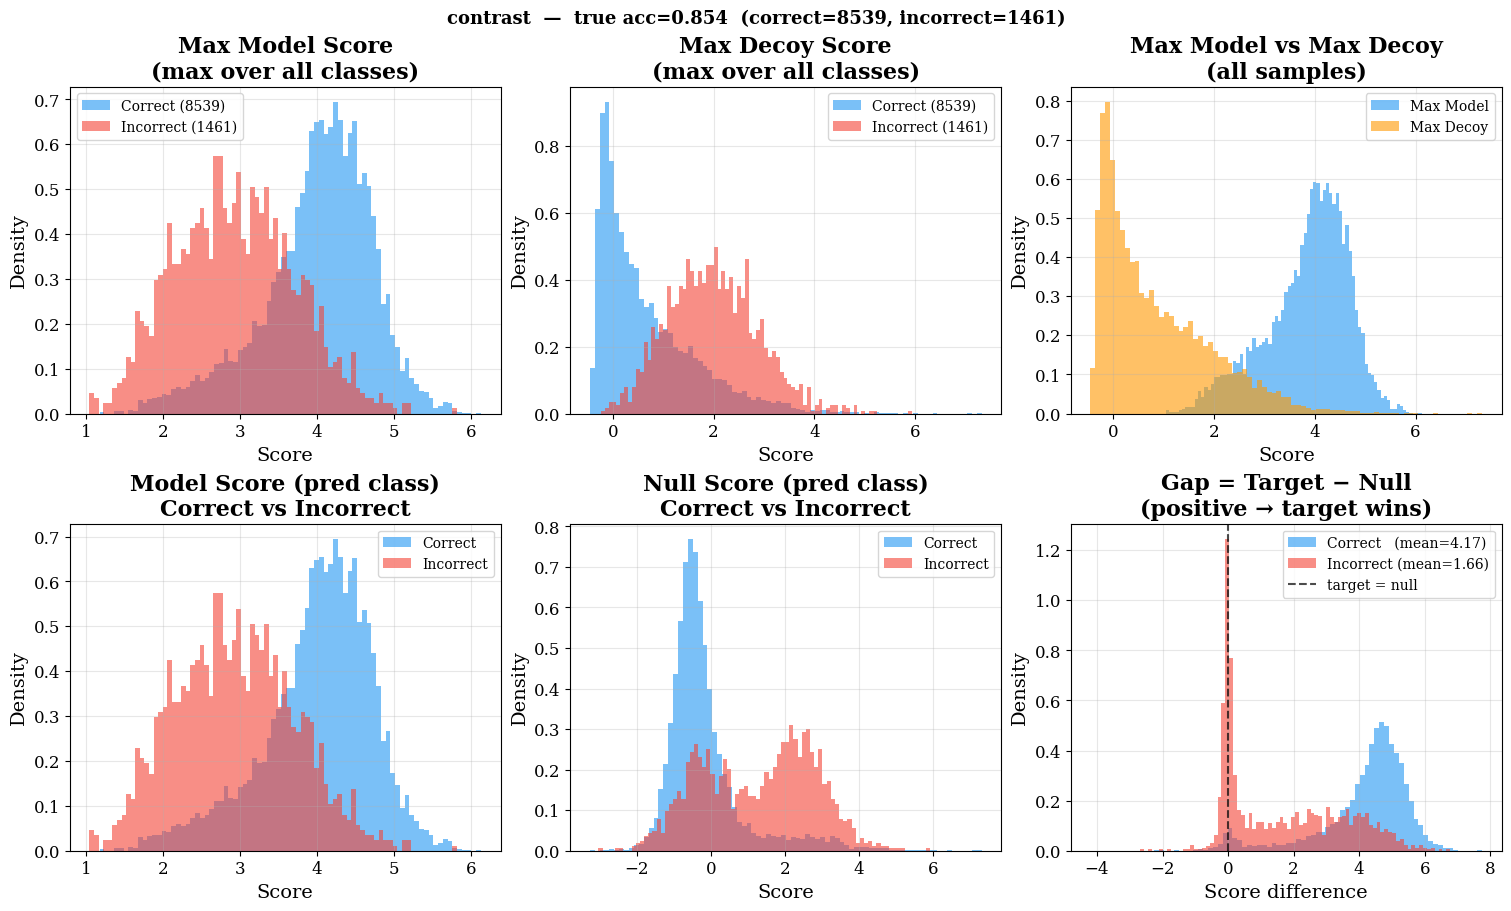

=== contrast — SUMMARY ===

Max MODEL score:
  Correct   : mean=4.010  std=0.713  [1.177, 6.131]
  Incorrect : mean=2.934  std=0.771  [1.042, 5.818]

Max DECOY score:
  Correct   : mean=0.672  std=0.970  [-0.456, 7.321]
  Incorrect : mean=1.988  std=0.898  [-0.237, 5.937]

Gap (target - null) at pred class:
  Correct   : mean=4.171  std=1.418
  Incorrect : mean=1.660  std=1.789

Target wins (pred class):
  Correct   : 0.977
  Incorrect : 0.775

Max model > max decoy:
  Correct   : 0.975
  Incorrect : 0.760


In [32]:
corruption_name = 'contrast'
model_scores, decoy_scores, labels = score_shift_flow.generate_decoys(
    test_corrupted_score_datasets[corruption_name], device=DEVICE)

n = len(model_scores)
pred_classes  = model_scores.argmax(axis=1)
target_scores = model_scores[np.arange(n), pred_classes]   # max model score
null_scores   = decoy_scores[np.arange(n), pred_classes]   # null for pred class

# Also max over all classes
max_model = model_scores.max(axis=1)
max_decoy = decoy_scores.max(axis=1)

correct_mask   = pred_classes == labels
incorrect_mask = ~correct_mask

true_acc = correct_mask.mean()

fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
fig.suptitle(f'{corruption_name}  —  true acc={true_acc:.3f}  '
             f'(correct={correct_mask.sum()}, incorrect={incorrect_mask.sum()})',
             fontweight='bold', fontsize=13)

bins = 80

# ── 1. Max model score: correct vs incorrect ──────────────────────────────
ax = axes[0, 0]
ax.hist(max_model[correct_mask],   bins=bins, alpha=0.6, density=True,
        color='#2196F3', label=f'Correct ({correct_mask.sum()})')
ax.hist(max_model[incorrect_mask], bins=bins, alpha=0.6, density=True,
        color='#F44336', label=f'Incorrect ({incorrect_mask.sum()})')
ax.set_title('Max Model Score\n(max over all classes)', fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# ── 2. Max decoy score: correct vs incorrect ──────────────────────────────
ax = axes[0, 1]
ax.hist(max_decoy[correct_mask],   bins=bins, alpha=0.6, density=True,
        color='#2196F3', label=f'Correct ({correct_mask.sum()})')
ax.hist(max_decoy[incorrect_mask], bins=bins, alpha=0.6, density=True,
        color='#F44336', label=f'Incorrect ({incorrect_mask.sum()})')
ax.set_title('Max Decoy Score\n(max over all classes)', fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# ── 3. Max model vs max decoy (both together) ─────────────────────────────
ax = axes[0, 2]
ax.hist(max_model, bins=bins, alpha=0.6, density=True,
        color='#2196F3', label='Max Model')
ax.hist(max_decoy, bins=bins, alpha=0.6, density=True,
        color='#FF9800', label='Max Decoy')
ax.set_title('Max Model vs Max Decoy\n(all samples)', fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# ── 4. Pred-class score: correct vs incorrect ─────────────────────────────
ax = axes[1, 0]
ax.hist(target_scores[correct_mask],   bins=bins, alpha=0.6, density=True,
        color='#2196F3', label='Correct')
ax.hist(target_scores[incorrect_mask], bins=bins, alpha=0.6, density=True,
        color='#F44336', label='Incorrect')
ax.set_title('Model Score (pred class)\nCorrect vs Incorrect', fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# ── 5. Pred-class null score: correct vs incorrect ────────────────────────
ax = axes[1, 1]
ax.hist(null_scores[correct_mask],   bins=bins, alpha=0.6, density=True,
        color='#2196F3', label='Correct')
ax.hist(null_scores[incorrect_mask], bins=bins, alpha=0.6, density=True,
        color='#F44336', label='Incorrect')
ax.set_title('Null Score (pred class)\nCorrect vs Incorrect', fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# ── 6. Gap = target - null: correct vs incorrect ──────────────────────────
ax = axes[1, 2]
gap_correct   = target_scores[correct_mask]   - null_scores[correct_mask]
gap_incorrect = target_scores[incorrect_mask] - null_scores[incorrect_mask]
ax.hist(gap_correct,   bins=bins, alpha=0.6, density=True,
        color='#2196F3', label=f'Correct   (mean={gap_correct.mean():.2f})')
ax.hist(gap_incorrect, bins=bins, alpha=0.6, density=True,
        color='#F44336', label=f'Incorrect (mean={gap_incorrect.mean():.2f})')
ax.axvline(0, color='black', linestyle='--', linewidth=1.5,
           alpha=0.7, label='target = null')
ax.set_title('Gap = Target − Null\n(positive → target wins)', fontweight='bold')
ax.set_xlabel('Score difference')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

os.makedirs('figures/diagnostics', exist_ok=True)
plt.savefig(f'figures/diagnostics/full_score_dist_{corruption_name}.png',
            dpi=300, bbox_inches='tight')
plt.savefig(f'figures/diagnostics/full_score_dist_{corruption_name}.pdf',
            bbox_inches='tight')
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────
print(f"=== {corruption_name} — SUMMARY ===")
print(f"\nMax MODEL score:")
print(f"  Correct   : mean={max_model[correct_mask].mean():.3f}  "
      f"std={max_model[correct_mask].std():.3f}  "
      f"[{max_model[correct_mask].min():.3f}, {max_model[correct_mask].max():.3f}]")
print(f"  Incorrect : mean={max_model[incorrect_mask].mean():.3f}  "
      f"std={max_model[incorrect_mask].std():.3f}  "
      f"[{max_model[incorrect_mask].min():.3f}, {max_model[incorrect_mask].max():.3f}]")

print(f"\nMax DECOY score:")
print(f"  Correct   : mean={max_decoy[correct_mask].mean():.3f}  "
      f"std={max_decoy[correct_mask].std():.3f}  "
      f"[{max_decoy[correct_mask].min():.3f}, {max_decoy[correct_mask].max():.3f}]")
print(f"  Incorrect : mean={max_decoy[incorrect_mask].mean():.3f}  "
      f"std={max_decoy[incorrect_mask].std():.3f}  "
      f"[{max_decoy[incorrect_mask].min():.3f}, {max_decoy[incorrect_mask].max():.3f}]")

print(f"\nGap (target - null) at pred class:")
print(f"  Correct   : mean={gap_correct.mean():.3f}  std={gap_correct.std():.3f}")
print(f"  Incorrect : mean={gap_incorrect.mean():.3f}  std={gap_incorrect.std():.3f}")

print(f"\nTarget wins (pred class):")
print(f"  Correct   : {(target_scores[correct_mask]   > null_scores[correct_mask]).mean():.3f}")
print(f"  Incorrect : {(target_scores[incorrect_mask] > null_scores[incorrect_mask]).mean():.3f}")

print(f"\nMax model > max decoy:")
print(f"  Correct   : {(max_model[correct_mask]   > max_decoy[correct_mask]).mean():.3f}")
print(f"  Incorrect : {(max_model[incorrect_mask] > max_decoy[incorrect_mask]).mean():.3f}")

In [33]:
import pickle

# Dictionary to store all the data
all_data = {}

# Clean test set
print("\nProcessing: cifar10_test (clean)")
test_scores, test_decoys, test_labels = score_shift_flow.generate_decoys(
    test_score_dataset, device=DEVICE)
all_data['cifar10_test'] = {
    'model_scores': test_scores,
    'decoy_scores': test_decoys,
    'true_labels': test_labels
}

# All corruptions
for corruption_name, score_dataset in test_corrupted_score_datasets.items():
    print(f"\nProcessing: {corruption_name}")
    model_scores, decoy_scores, labels = score_shift_flow.generate_decoys(
        score_dataset, device=DEVICE)
    all_data[corruption_name] = {
        'model_scores': model_scores,
        'decoy_scores': decoy_scores,
        'true_labels': labels
    }

# Save to pickle file
with open('dataset_scores_and_labels.pkl', 'wb') as f:
    pickle.dump(all_data, f)

print("\n✓ Saved all data to dataset_scores_and_labels.pkl")


Processing: cifar10_test (clean)

Processing: gaussian_noise

Processing: shot_noise

Processing: impulse_noise

Processing: defocus_blur

Processing: glass_blur

Processing: motion_blur

Processing: zoom_blur

Processing: snow

Processing: frost

Processing: fog

Processing: brightness

Processing: contrast

Processing: elastic_transform

Processing: pixelate

Processing: jpeg_compression

Processing: speckle_noise

Processing: gaussian_blur

Processing: spatter

Processing: saturate

✓ Saved all data to dataset_scores_and_labels.pkl


In [35]:
import pickle

with open('dataset_scores_and_labels.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

#all corruptions
for corruption_name in loaded_data.keys():
    corruption_data = loaded_data[corruption_name]
    model_scores = corruption_data['model_scores']
    decoy_scores = corruption_data['decoy_scores']
    labels = corruption_data['true_labels']


# Access specific corruption
cifar10_clean = loaded_data['cifar10_test']
model_scores = cifar10_clean['model_scores']
decoy_scores = cifar10_clean['decoy_scores']
labels = cifar10_clean['true_labels']

# Or access a specific corruption like 'gaussian_noise'
gaussian_data = loaded_data['gaussian_noise']

In [36]:
def compute_mixmax_accuracy_at_threshold(df_mixmax, q_threshold=0.05):
    """
    At FDR threshold q*:
      - Accept only samples with q_value <= q*  (discoveries)
      - Among these, estimated accuracy = 1 - q*
      - True accuracy = actual accuracy among these samples
    
    This is the RIGHT comparison: we are not estimating accuracy
    on ALL samples, but on the ACCEPTED subset.
    """
    mask = df_mixmax['q_values_mixmax'] <= q_threshold
    n_accepted = mask.sum()
    
    if n_accepted == 0:
        return None
    
    accepted = df_mixmax[mask]
    true_acc_at_threshold = (
        accepted['predicted_class'] == accepted['label']
    ).mean()
    estimated_acc_at_threshold = 1.0 - q_threshold
    
    return {
        'n_accepted'     : n_accepted,
        'n_total'        : len(df_mixmax),
        'frac_accepted'  : n_accepted / len(df_mixmax),
        'estimated_acc'  : estimated_acc_at_threshold,
        'true_acc'       : true_acc_at_threshold,
        'error'          : abs(estimated_acc_at_threshold - true_acc_at_threshold),
    }


print("\n" + "="*80)
print("RUNNING EVALUATIONS  (fair comparison)")
print("="*80)

Q_THRESHOLDS = [0.05, 0.10, 0.20]

source_logits, source_decoy_scores, source_labels = score_shift_flow.generate_decoys(
    train_score_dataset, device=DEVICE)
source_logits_t = torch.tensor(source_logits).to(DEVICE)
source_labels_t = torch.tensor(source_labels).to(DEVICE)
temp = calibration_temp(source_logits_t, source_labels_t)

all_results    = []   # Mix-Max results (per threshold)
baseline_results = [] # Baseline results (whole dataset)

for corruption_name, score_dataset in test_corrupted_score_datasets.items():
    print(f"\nProcessing: {corruption_name}")
    model_scores, decoy_scores, labels = score_shift_flow.generate_decoys(
        score_dataset, device=DEVICE)

    target_logits_t = torch.tensor(model_scores).to(DEVICE)
    target_labels_t = torch.tensor(labels).to(DEVICE)

    # True accuracy on FULL dataset (for baselines)
    true_acc_full = (target_logits_t.argmax(1) == target_labels_t).float().mean().item()

    # ── Mix-Max: accuracy at each FDR threshold ───────────────────────────
    df_mixmax = control_fdr_mixmax(model_scores, labels, decoy_scores)

    print(f"  True acc (full dataset): {true_acc_full:.3f}")
    print(f"  Mix-Max results:")

    for q_thresh in Q_THRESHOLDS:
        res = compute_mixmax_accuracy_at_threshold(df_mixmax, q_threshold=q_thresh)
        if res is None:
            print(f"    q<={q_thresh:.2f}: no accepted samples")
            continue

        print(f"    q<={q_thresh:.2f}: "
              f"accepted={res['n_accepted']}/{res['n_total']} "
              f"({res['frac_accepted']*100:.1f}%)  "
              f"est_acc={res['estimated_acc']:.3f}  "
              f"true_acc={res['true_acc']:.3f}  "
              f"error={res['error']:.3f}")

        all_results.append({
            'corruption'        : corruption_name,
            'method'            : f"Mix-Max (q<={q_thresh:.2f})",
            'q_threshold'       : q_thresh,
            'estimated_accuracy': res['estimated_acc'],
            'true_accuracy'     : res['true_acc'],      # ← accuracy on ACCEPTED subset
            'true_acc_full'     : true_acc_full,        # ← full dataset accuracy
            'n_accepted'        : res['n_accepted'],
            'n_total'           : res['n_total'],
            'frac_accepted'     : res['frac_accepted'],
            'error'             : res['error'],
        })

    # ── Baselines: accuracy on full dataset ───────────────────────────────
    scaled_source = source_logits_t / temp
    scaled_target = target_logits_t / temp

    print(f"  Baselines (full dataset, true_acc={true_acc_full:.3f}):")
    for method_name, method_func in BASELINE_METHODS.items():
        try:
            estimate = method_func(scaled_source, source_labels_t, scaled_target)
            error    = abs(estimate - true_acc_full)
            baseline_results.append({
                'corruption'        : corruption_name,
                'method'            : method_name,
                'estimated_accuracy': estimate,
                'true_accuracy'     : true_acc_full,
                'error'             : error,
            })
            print(f"    {method_name}: est={estimate:.3f}  "
                  f"true={true_acc_full:.3f}  error={error:.3f}")
        except Exception as e:
            print(f"    {method_name}: FAILED ({e})")

mixmax_df   = pd.DataFrame(all_results)
baseline_df = pd.DataFrame(baseline_results)

print("\n✓ All evaluations complete")

# ── Summary ───────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("SUMMARY")
print("="*80)

print("\nMix-Max MAE by threshold:")
for q_thresh in Q_THRESHOLDS:
    df_q = mixmax_df[mixmax_df['q_threshold'] == q_thresh]
    if len(df_q) == 0:
        continue
    mae          = df_q['error'].mean()
    frac_mean    = df_q['frac_accepted'].mean()
    print(f"  q<={q_thresh:.2f}: MAE={mae:.4f}  "
          f"avg accepted={frac_mean*100:.1f}% of samples")

print("\nBaseline MAE (full dataset):")
for method in baseline_df['method'].unique():
    df_m = baseline_df[baseline_df['method'] == method]
    mae  = df_m['error'].mean()
    print(f"  {method}: MAE={mae:.4f}")

# ── Save ──────────────────────────────────────────────────────────────────
os.makedirs('figures/comparison', exist_ok=True)
mixmax_df.to_csv('figures/comparison/mixmax_results.csv',   index=False)
baseline_df.to_csv('figures/comparison/baseline_results.csv', index=False)
print("\n✓ Results saved")


RUNNING EVALUATIONS  (fair comparison)

Processing: gaussian_noise
  True acc (full dataset): 0.371
  Mix-Max results:
    q<=0.05: accepted=3544/10000 (35.4%)  est_acc=0.950  true_acc=0.585  error=0.365
    q<=0.10: accepted=5362/10000 (53.6%)  est_acc=0.900  true_acc=0.497  error=0.403
    q<=0.20: accepted=9680/10000 (96.8%)  est_acc=0.800  true_acc=0.380  error=0.420
  Baselines (full dataset, true_acc=0.371):
    ATC: est=0.459  true=0.371  error=0.088
    ATC-NE: est=0.440  true=0.371  error=0.069
    AC: est=0.695  true=0.371  error=0.324
    DOC: est=0.676  true=0.371  error=0.305
    COT: est=0.443  true=0.371  error=0.072

Processing: shot_noise
  True acc (full dataset): 0.512
  Mix-Max results:
    q<=0.05: accepted=4024/10000 (40.2%)  est_acc=0.950  true_acc=0.763  error=0.187
    q<=0.10: accepted=6624/10000 (66.2%)  est_acc=0.900  true_acc=0.632  error=0.268
    q<=0.20: accepted=10000/10000 (100.0%)  est_acc=0.800  true_acc=0.512  error=0.288
  Baselines (full dataset,